In [1]:
# Import some starting packages here. 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project Title: Recording quality elucidation and identification of highly-responsive units in a working memory electrophysiology dataset

## Project Outline
1. Introduction
    1. Dataset
2. Data Import and Cleanup
    1. Organizational Logic of the Dataset
    2. Data Import
    3. Data Cleanup
    4. DataFrame Creation to Aggregate Data Across Brain Regions, Across Subjects
    5. Master Series Summary
3. Analysis and Visualization
    1. KDE plotting reveals high amounts of noise among all brain areas
    1. Outline of Analysis Methods
    3. PCA plot reveals little variance between screen and task among brain areas
    4. Correlation matrix of brain area activity by session using Peak SNR vs. Mean SNR
        1. Visualizaton of Percentages of Reliable Recording Sessions Across Brain Areas
    6. Filtering highly-responsive units using Peak SNR thresholds and Mean SNR thresholds
    7. Extraction and visualization of highly-responsive units 
4. Discussion
5. References

# 1. Introduction 

This section provides an introduction to the dataset and the research question. 

### The Dataset

Directions to the Dataset can be found at the top of References. 

In *Dataset of human-single neuron activity during a Sternberg working memory task*, Kyzar *et. al* present a dataset of 1809 single neurons recorded from the human medial temporal lobe (amygdala and hippocampus) and medial frontal lobe (anterior cingulate cortex, pre-supplementary motor area, ventral medial prefrontal cortex) across 41 sessions from 21 epilepsy patients while testing them in a Sternberg Working Memory task. As the name suggests, the Sternberg working memory task is a a common test used to assess working memory function in cognitive science (Klabes *et. al* 2021). Invasive extracellular electrophysiological recording methods were used. 

In this study, 20 subjects first performed a screening task (907 neurons) with the authors intending to identify images for which concept cells were present. Concept cells are defined as cells that preferentially response to a particular image. 

Subjects then performed a working memory task (902 neurons), in which they were sequentially presented with 1–3 images for which highly selective cells were present and, following a maintenance period, were asked if the probe was identical to one of the maintained images. The authors' intention with this data was to identify concept cells for particular images.  

This dataset presents post-sorted but unorganized electrophysiological data from extracelllar electrodes. The relevant features that will be extracted in this project include information about location, peak and mean SNR, and isolation distance. 
1) Location: The location that the electrode was placed in to record each unit, both on an XYZ axis defined by the authors, and by brain region. 
2) Peak SNR: Peak Signal-to-Noise ratio for each unit. Signal-to-noise ratio defines the signal level compared to a level of background noise. 
3) Mean SNR: Mean Signal-to-Noise ratio for each unit. 
4) Isolation distance: *Isolation distance calculates the size of the 96-dimensional sphere that includes as many "other" spikes as are contained in the original unit's cluster, after normalizing the clusters by their standard deviation in each dimension (Mahalanobis distance). The higher the isolation distance, the more a unit is separated from its neighbors in PC space, and therefore the lower the likelihood that it's contamined by spikes from multiple units.* This definition is quoted from the following module: (Allensdk) *Unit Quality Metrics.* 

### Background

I initially chose this dataset because I was interested in investigating the mechansims of working memory, and was interested in potentially using this dataset to analyze population level dynamics during the working memory task. However, some limitations necesitated a shift in the research direction. 

First, while spike sorting, clustering, and waveform plotting of electrophysiology data is already difficult without higher order algorithms, the authors also organized time-series in a dimension that did not match the electrophysiology data. Significant abstraction would be required for time series alignment. Thus, waveform analysis is unrealistic in the given environment. 

Some additional caveats to the dataset, however, provide interesting corners in which to examine the dataset. For example: 
1) Each subject in the task is diagnosed with epilepsy in a different region of the brain, and the authors thus differentially inserted electrodes across the subjects. Not all brain regions were measured across all subjects. 
2) Authors only minimally recorded the vMPC, the area of the brain which is thought to be the most most implicated in working memory (Chai *et. al* 2018), instead opting to more rigorously record less-implicated brain regions such as the amygdala. 

Thus, though the authors have done a significant amount of preprocessing and spike sorting on this dataset, much is left to be asked regarding the recording quality of units in the dataset, the consistency of neural responses between subjects, and their potential for further analysis. Using the tools available libraries such as NumPy, Pandas, and Scikit Learn, some basic analysis and visualization can be performed on the metrics provided in this dataset to analyze the quality of its recordings and their consistency across subjects. 

**This project first aims to use the aforementioned libraries to compare and analyze relationships between the provided metrics across subjects and brain areas to elucidate the quality and consistency of the neural recordings in this dataset.**

**Then, this project aims to identify potentially significant units in this working memory task and the brain areas in which they are located using statistical analysis on the metrics available. Hopefully, this analysis will allow for the preliminary identifcation of brain areas with significant activity in the working memory task.** These units, which generally display the highest SNR, are likely indicative of genuine neural activity in response to a cognitive task, and will be referred to throughout the project as 'high response' units. These have the greatest potential for further analysis. Future computational and waveform analysis on those identified units could potentially lead to the identificatiion of important single-cells or neuronal populations, such as concept cells.

# 2. Data Import and Cleanup
The following section details the organization structure of the datafiles, imports the dataset, and walks through the logic of the data cleanup algorithm.

## 2A. Organizational Structure of the Datafiles

This dataset presents data across two sessions for 20 of the 21 subjects. 
1) As previously described, each subject has electrode data for a 'screen' session. 
2) Each subject has electrode data for the working memory 'task' session. 
Thus, each subject has data for two sessions. Note that Subject 19 is missing screening data, and thus will be excluded from the analysis. 

Each session is composed of two related csvs. 
1) An 'electrode' csv containing all of the electrodes used in the session. 
2) A session data csv containing all of the readouts of the electrodes. Note that a single electrode can have multiple readouts in a session. 

Thus, the structure of the dataset contains four relevant files for one subject: 
1) The screen session electrode information
2) The screen session electrode readouts
3) The task session electrode information
4) The task session electrode information

The datafiles are named as follows: *sub-#_ses-#_ecephys* for the readouts, and *sub-#_ses-#_ecephys elecrodes* for the electrode information. *Sub-#* refers to the subject number and *ses-#* refers to the session number, with 1 being the screen and 2 being the task. **The datafiles for subject 1 are examined here to illustrate this.**

In [2]:
# (1)
# Subject 1 screen session electrode readouts
subj_1_screen = pd.read_csv('Sterberg Working Memory Data - sub-1_ses-1_ecephys.csv')

# (2)
# Subject 1 screen session electrode information
subj_1_screen_electrodes = pd.read_csv('Sterberg Working Memory Data - sub-1_ses-1_ecephys electrodes.csv')

# (3)
# Subject 1 task session electrode readouts
subj_1_task = pd.read_csv('Sterberg Working Memory Data - sub-1_ses-2_ecephys.csv')

# (4)
# Subject 1 task session electrode information
subj_1_task_electrodes = pd.read_csv('Sterberg Working Memory Data - sub-1_ses-2_ecephys electrodes.csv')

**All of the csvs pertaining to electrode readout contain the same 7 columns.**
1) **id** is a duplicate of the index column. 
2) **electrodes** corresponds to the electrode number that was doing the recording. 
3) **clusterID_orgin** is the clusterID assigned to each unit after preprocessing by the authors, intended to be used for data cross-referencing. 
4) **waveforms_mean_snr** is the mean SNR of the unit.
5) **waveforms_peak_snr** is the peak SNR of the unit. 
6) **waveforms_isolation_distance** is the calculated isolation distance of the unit. Note that we can see that this column contains np.nans. 
7) **waveforms_mean_proj_dist** is the mean projection distance of the unit's waveform (i.e, its wavelength). 

In [3]:
subj_1_screen.head()

,id,electrodes,clusterID_orig,waveforms_mean_snr,waveforms_peak_snr,waveforms_isolation_distance,waveforms_mean_proj_dist
0,0,0,440,0.890212,4.813635,NaN,0.000000
1,1,1,647,1.295157,5.043108,NaN,9.285786
2,2,1,662,2.923340,10.915611,22.314957,10.866820
3,3,1,687,2.047083,7.231902,10.550599,6.870165
4,4,2,1170,1.782234,6.843394,277.260038,6.828680


In [4]:
subj_1_task.head()

,id,electrodes,clusterID_orig,waveforms_mean_snr,waveforms_peak_snr,waveforms_isolation_distance,waveforms_mean_proj_dist
0,0,0,1188,1.632053,5.296655,22.181612,0.000000
1,1,1,1143,1.715558,5.328233,66.939296,5.790398
2,2,1,1230,0.898435,3.493311,22.535248,5.790398
3,3,2,1540,1.597233,5.592891,NaN,5.401200
4,4,2,1767,0.919820,3.478548,8.856038,5.401200


**Similarly, all of the csvs pertaining to electrode information contain the same 9 columns.**
1) **id** is the electrode ID, which corresponds to the 'electrodes' column in the readout dataset. 
2) **x, y, and z** correspond to the spatial postion of the electrode, in terms of MINI coordinates (mm).  
3) **location** is brain region in which the electrode was placed.  
4) **waveforms_mean_snr** is the mean SNR of the unit.
5) **filtering, group, group_name, and origChannel** are additonal metrics related to the preprocessing of the electrode data. **filtering** and **group_name** are redundant accross rows, and group and origChannel are irrelevant to our analysis. 

In [5]:
subj_1_screen_electrodes.head()

,id,x,y,z,location,filtering,group,group_name,origChannel
0,0,-20.65,-21.7,-12.95,hippocampus_left,300-3000Hz,24,micros,31
1,1,3.96,29.04,25.04,dorsal_anterior_cingulate_cortex_right,300-3000Hz,54,micros,33
2,2,3.96,29.04,25.04,dorsal_anterior_cingulate_cortex_right,300-3000Hz,2,micros,34
3,3,3.96,29.04,25.04,dorsal_anterior_cingulate_cortex_right,300-3000Hz,0,micros,35
4,4,3.96,29.04,25.04,dorsal_anterior_cingulate_cortex_right,300-3000Hz,0,micros,36


In [6]:
subj_1_task_electrodes.head()

,id,x,y,z,location,filtering,group,group_name,origChannel
0,0,3.96,29.04,25.04,dorsal_anterior_cingulate_cortex_right,300-3000Hz,80,micros,33
1,1,3.96,29.04,25.04,dorsal_anterior_cingulate_cortex_right,300-3000Hz,59,micros,34
2,2,3.96,29.04,25.04,dorsal_anterior_cingulate_cortex_right,300-3000Hz,2,micros,35
3,3,3.96,29.04,25.04,dorsal_anterior_cingulate_cortex_right,300-3000Hz,0,micros,36
4,4,3.96,29.04,25.04,dorsal_anterior_cingulate_cortex_right,300-3000Hz,0,micros,37


Note that for any electrode information datafile, the end of the datafile *always* contains many rows of sentinels. 

In [7]:
subj_1_task_electrodes.tail()

,id,x,y,z,location,filtering,group,group_name,origChannel
171,<>,<>,<>,<>,<>,<>,0,<>,<>
172,<>,<>,<>,<>,<>,<>,0,<>,<>
173,<>,<>,<>,<>,<>,<>,0,<>,<>
174,<>,<>,<>,<>,<>,<>,0,<>,<>
175,<>,<>,<>,<>,<>,<>,0,<>,<>


To summarize, each subject is associated with four relevant datafiles in the formats of the above example. This format is consistent throughout the dataset. 

In the working directory, the files are saved in numerical order. As follows: 
> sub-10_ses-1_ecephys electrodes.csv

> sub-10_ses-1_ecephys.csv

> sub-10_ses-2_ecephys electrodes.csv

> sub-10_ses-2_ecephys.csv

> sub-11_ses-1_ecephys electrodes.csv

> sub-11_ses-1_ecephys.csv


And so forth. 

#### **This section of the project uses:**
 - df.head() and df.tail()
 - pd.read_csv()

## 2B.  Dataset Import

First, all of the csv files must be read in. 2 datafiles per session across forty sessions lends 80 csv files to be read in. Thus, a bulk read in method that accesses the global working directory will be used. 

**Tutorial used:** (SaturnCloud) *How to Read Multiple CSV Files into Python Pandas Dataframe.*

Note that all tutorials, modules, and documentation used for coding help are included in references at the end of the project. 

In [8]:
# First, get the working directory so I know where to tell glob to pull the projects from. 
import os
print(os.getcwd())

/Users/kathrynguo/Downloads/NSCI 21820/NSCI 21820 Project Data


In [9]:
# I'll create an empty list to store all of the csv files called csvs. 
csvs = []
# Since I'll simply be looping through the list to obtain the csv files, and don't need to access the datafiles in 
# any more abstract way, a list is a sufficient data structure for this purpose. 

In [10]:
import glob 
csv_files = glob.glob('/Users/kathrynguo/Downloads/NSCI 21820/NSCI 21820 Project Data/*.csv')

## DEBUGGING STATEMENT: Ensure that all of the csv files have been properly accessed by printing them. 
# print(csv_files)

# The structure of csv_files is a list containing all of the csv_files pre-read-in. 
print(type(csv_files))

<class 'list'>


In [11]:
# Since the file names are sorted in numerical order in the working directory, I will sort the csv_files list to maintain 
# consistency in order between the read-ins and the working directory. See markdown cell for the importance of this action.
csv_files.sort()

# Then, for each item in the csv_files list, read in the .csv and add it to the csvs list. 
csvs = [pd.read_csv(i) for i in csv_files]

**Maintaining the numerical order of the csv read-ins is essential for later data analysis.** 
By ensuring preservation of numerical order, it can be ensured that the intended .csv files are easily accessed by numerical indexing, faciliting naming, cleanup, and addition to further data structures. 

Since the order of the csv read-ins was maintained, the csvs list adheres the following indexing pattern: 

 - Recall that there are four files for each subject, in the following order: screen electrode information, screen electrode readout, task electrode information, and task electrode readout. 
 - Thus, the folowing indexing pattern is maintained: 
    - index = 0, 4, 8, 12, and so forth is the screen electrode information for each subject. 
    - index = 1, 5, 9, 13, and so forth is the screen electrode readout for each subject. 
    - index = 2, 6, 10, 14, and so forth is the task electrode information for each subject. 
    - index = 3, 7, 11, 15, and so forth is the task electrode readout for each subject. 
    - index = [0, 1, 2, 3] correspond to the data for a single subject, [4, 5, 6, 7] for the next subject, and so forth. 

So, in calling csvs[0], the screen electrode information datafile for Subject 10 is called (in numerical sorting, 10 precedes 1, and 20 precedes 2). 

In [12]:
# Let's look at the first electrode datafile. 
csvs[0].head()

,id,x,y,z,location,filtering,group,group_name,origChannel
0,0,-7,25.7,44.9,pre_supplementary_motor_area_left,300-3000Hz,24,micros,1
1,1,-7,25.7,44.9,pre_supplementary_motor_area_left,300-3000Hz,54,micros,2
2,2,-7,25.7,44.9,pre_supplementary_motor_area_left,300-3000Hz,2,micros,3
3,3,-7,25.7,44.9,pre_supplementary_motor_area_left,300-3000Hz,0,micros,4
4,4,-7,25.7,44.9,pre_supplementary_motor_area_left,300-3000Hz,0,micros,5


In [13]:
# As expected, the csvs list contains 80 DataFrames. 
len(csvs)

80

The length of the csv file corroborates the expected number of datafiles, indicating that the data was successfully read in. 

**Techniques used in this section of the project:**
 - import os to get working directory
 - import glob to read in files stored in the global environment
 - .sort(), type(), and len()
 - for loop
 - list comprehension: [pd.read_csv(i) for i in csv_files]
 - understanding the structure of a list

## 2C. Data Cleanup

The datafiles must be cleaned in the following ways. 
1) Drop rows containing the '<>' null value in any electrode information datafile. 
2) Ensure that any null value is consistently a np.nan, rather than just a string that = 'NaN'
3) Ensure that columns contain the correct dtype for merging
4) Drop irrelvant columns in the electrodes dataset: *filtering, group_name, origChannel, and group*
5) Merge the cleaned electrode information and electrode readout files
    1) Recall that the 'id' column in each electrode information dataset corresponds to the 'electrodes' column in the readout dataset, but that there are multiple readouts for one electrode. 
    2) We must also ensure that the merged dataset contains the correct columns. 
   
A merge across the electrode readout and electrode information files for one session yields a cleaned DataFrame for one recording session. There are forty sessions. 
    
To accomplish this bulk clean, a function called 'clean' will first be defined. 'clean' passes through the electrode information and electrode readout datafile for one session, and returns a merged, cleaned DataFrame for that session. 

In [14]:
def clean(readout, electrodes): # Define a function called clean() and pass through the readout and electrodes. 
    
    # Make a copy to avoid modifying the original DataFrame. This makes it easier for debugging, so that the dataframe
    # does not need to be constently reset. 
    readout_copy = readout.copy()  
    
    # Maintain consistency across null values, to ensure that everything is indeed a np.nan and not just a string of 'NaN'.
    readout_copy['waveforms_isolation_distance'].replace([np.nan, 'NaN'], np.nan, inplace=True)
   
    # Copy the electrode information file. 
    electrodes_copy = electrodes.copy()
    
    # The electrode information file has '<>' as null values. 
    # Reading in '<>' as a sentinel in our global read in method requires tricky indexing, as
    # only every other contains these as sentinels. Thus, I will use the method of dropping them here. 
    na_val = '<>'
    
    # Use a lamda function containing a logical operator to apply a mask along each row
    null_mask = electrodes.apply(lambda row: na_val in row.values, axis=1)
    # Use null_mask to drop rows containing '<>'
    electrodes_copy = electrodes_copy[~null_mask]
    
    # type(df2_copy['id']) lends 'object'
    # To properly merge later, we need to downcast the 'id' column from an object to an int
    electrodes_copy['id'] = electrodes_copy['id'].astype(int)

    # Drop the irrelvant columns in the electrode dataset
    electrodes_copy.drop(columns=['filtering', 'group_name', 'origChannel', 'group'], inplace=True)
    
    ## DEBUGGING STATEMENT to ensure proper drops 
    # print(electrodes_copy)
    
    # Establish the index on our new, merged dataframe
    index = ['location', 'electrodes', 'clusterID_orig', 'waveforms_mean_snr', 'waveforms_peak_snr',
            'waveforms_isolation_distance', 'waveforms_mean_proj_dist', 'x', 'y', 'z']
    
    # Perform a merge: add in columns from the electrode DataFrame based on matching values in the 'electrodes' column
    merged_df = pd.merge(readout_copy, electrodes_copy, left_on='electrodes', right_on='id')
    
    # If statement to drop the x/y id columns if they're present. They can sometimes be added on the merge. 
    if 'id_x' in merged_df.columns and 'id_y' in merged_df.columns:
        merged_df.drop(columns=['id_x', 'id_y'], inplace=True)
    
    merged_df = merged_df[index]
    
    return merged_df  # Return the merged DataFrame

Note that another method to identify '<>' as a null value is reading it in as a sentinel when reading in the csv, like so: 

> <code> subj_1_task_electrodes = pd.read_csv('Sterberg Working Memory Data - sub-1_ses-2_ecephys electrodes.csv', na_values = ['<>']) </code>

However, reading in '<>' as a sentinel in our global read in method requires tricky indexing, as only every other .csv contains '<>' as null values. Thus, the <code> .apply(lambda) </code> method is used. 

In order to effectively clean and merge 80 files, a while loop will be used to iterate through the csvs list. 

The while loop allows for careful manipulation of counter variables. This is useful for the unique indexing structure of the csvs list. Recall: 
  - index = 0, 4, 8, 12, and so forth is the screen electrode information for each subject. 
  - index = 1, 5, 9, 13, and so forth is the screen electrode readout for each subject. 
  - index = 2, 6, 10, 14, and so forth is the task electrode information for each subject. 
  - index = 3, 7, 11, 15, and so forth is the task electrode readout for each subject. 
  - index = [0, 1, 2, 3] correspond to the data for a single subject, [4, 5, 6, 7] for the next subject, and so forth.

In [15]:
# The counter variables are initiated respectively, starting at the first index.  
count_screen_electrodes = 0
count_screen_readout = 1
count_task_electrodes = 2
count_task_readout = 3

# Be sure to reinitialize these variables every time you start the while loop. 

In [16]:
# Now, we will initialize the while loop to iterate through all 80 of the csv files. 

i = 0 # Create the general while loop counter. 

# Create an empty list to store all of the cleaned DataFrames. The rationale for this will be apparent in the final data structure. 
cleaned_data = []

while (i < len(csvs)): 
    
    ### DEBUG STATEMENTS: Ensure correct indexing
    ## print("count_screen_readout:", count_screen_readout)
    ## print("count_screen_electrodes:", count_screen_electrodes)
    
    # Clean the screen data and assign the function output to a DataFrame called 'screen_data'
    screen_data = clean(csvs[count_screen_readout], csvs[count_screen_electrodes])
    # Then append it to the list. 
    cleaned_data.append(screen_data)

    # Move onto the next subject for both of these, which is four indices down, as previously explained. 
    count_screen_readout += 4
    count_screen_electrodes +=4
    
    ### DEBUG STATEMENTS: Ensure correct indexing
    ## print("count_task_readout:", count_task_readout)
    ## print("count_task_electrodes:", count_task_electrodes)
    
    # Same as above, but with the task session data.  
    task_data = clean(csvs[count_task_readout], csvs[count_task_electrodes])
    cleaned_data.append(task_data)
 
    # Move onto the next subject for both of these, which is four indices down, as previously explained. 
    count_task_readout += 4
    count_task_electrodes +=4
    
    # Up the counter by 4 to move onto the next subject, which is four indices down. 
    
    i +=4
    
    ### DEBUG STATEMENTS: Ensure correct indexing
    ## print('i: ', i)

<code>cleaned_data</code> is now a list containing all 40 cleaned DataFrames. 

In [17]:
# cleaned_data

# Return statement is commented out because the output is long, but you can comment it back in if you wish to see that list. 

<code>cleaned_data</code> could be sufficient to simply access the cleaned DataFrames without assigning them labels or names by solely using integer indexing. However, this is both disorganized and extremely limiting. 

Recall that the order that the .csv files are saved in the working directory is preserved throughout the entire data cleaning process due to the use of while loop iterations through the list. Additionally: 

 - The <code>csvs</code> list contains data for a subject in the following order: 
    1. screen electrode information
    2. screen electrode readout
    3. task electrode information
    4. task electrode readout
  - The <code>clean()</code> function merges the electrode_information and electrode_readout datafiles across one session together into one DataFrame. This one DataFrame is stored in </code> cleaned_data </code> . 
      - The <code>cleaned_data</code> list contains 40 DataFrames, as opposed to the 80 stored int the <code>csvs</code> list. 
  - <code>cleaned_data</code> list therefore contains 40 DataFrames in the following order: 

In [18]:
data_names = ['subj10_screen', 'subj10_task', 
              'subj11_screen', 'subj11_task',
              'subj12_screen', 'subj12_task',
              'subj13_screen', 'subj13_task',
              'subj14_screen', 'subj14_task',
              'subj15_screen', 'subj15_task',
              'subj16_screen', 'subj16_task',
              'subj17_screen', 'subj17_task',
              'subj18_screen', 'subj18_task',
              'subj1_screen', 'subj1_task',
              'subj20_screen', 'subj20_task',
              'subj21_screen', 'subj21_task',
              'subj2_screen', 'subj2_task',
              'subj3_screen', 'subj3_task',
              'subj4_screen', 'subj4_task',
              'subj5_screen', 'subj5_task',
              'subj6_screen', 'subj6_task',
              'subj7_screen', 'subj7_task',
              'subj8_screen', 'subj8_task',
              'subj9_screen', 'subj9_task']
# data_names is therefore the list that will be used index the 40 DataFrames in cleaned_data, as will be shown. 

In [19]:
len(data_names) # Affirm that we have the correct number of data names- we should have 40. 

40

Now, two parallel lists have been created. 
1) One called <code> cleaned_data </code>, containing all of the cleaned DataFrames. 
2) One called <code> data_names </code>, containing all of the subject and session IDs for all of the cleaned DataFrames. 

Since order has been preserved throughout the entire data cleaning process, at a given index of <code> cleaned_data </code>, the index at <code> data_names </code> will return the session and subject that that data belongs to. 

These two lists can be then be transformed into a Pandas series. 

In [20]:
subject_data = pd.Series(cleaned_data, index = data_names)

<code> subject_data </code> is the **master series** that will be used to extract all of the data for analysis. 

In this structure, the same DataFrame can be accessed through either label or integer indexing, which is essential for looping. 

In [21]:
subject_data.loc['subj10_screen']

,location,electrodes,clusterID_orig,waveforms_mean_snr,waveforms_peak_snr,waveforms_isolation_distance,waveforms_mean_proj_dist,x,y,z
0,pre_supplementary_motor_area_left,0,1103,0.685306,3.890334,22.671009,13.180377,-7,25.7,44.9
1,pre_supplementary_motor_area_left,0,860,2.862844,10.647989,24.932710,12.344006,-7,25.7,44.9
2,pre_supplementary_motor_area_left,0,931,2.253330,10.550504,24.413911,11.242594,-7,25.7,44.9
3,pre_supplementary_motor_area_left,0,1096,1.179923,4.887464,NaN,10.411253,-7,25.7,44.9
4,pre_supplementary_motor_area_left,1,1113,0.890976,3.778985,12.328650,5.236814,-7,25.7,44.9
...,...,...,...,...,...,...,...,...,...,...
69,amygdala_right,36,510,2.425993,10.742008,5895.237637,15.485633,19,-1.8,-15.9
70,amygdala_right,36,462,0.949669,3.338105,447.415356,15.485633,19,-1.8,-15.9
71,amygdala_right,37,1084,1.170011,5.589591,NaN,0.000000,19,-1.8,-15.9
72,amygdala_right,38,287,1.017418,5.275650,39.334744,5.746725,19,-1.8,-15.9


In [22]:
subject_data.iloc[0]

,location,electrodes,clusterID_orig,waveforms_mean_snr,waveforms_peak_snr,waveforms_isolation_distance,waveforms_mean_proj_dist,x,y,z
0,pre_supplementary_motor_area_left,0,1103,0.685306,3.890334,22.671009,13.180377,-7,25.7,44.9
1,pre_supplementary_motor_area_left,0,860,2.862844,10.647989,24.932710,12.344006,-7,25.7,44.9
2,pre_supplementary_motor_area_left,0,931,2.253330,10.550504,24.413911,11.242594,-7,25.7,44.9
3,pre_supplementary_motor_area_left,0,1096,1.179923,4.887464,NaN,10.411253,-7,25.7,44.9
4,pre_supplementary_motor_area_left,1,1113,0.890976,3.778985,12.328650,5.236814,-7,25.7,44.9
...,...,...,...,...,...,...,...,...,...,...
69,amygdala_right,36,510,2.425993,10.742008,5895.237637,15.485633,19,-1.8,-15.9
70,amygdala_right,36,462,0.949669,3.338105,447.415356,15.485633,19,-1.8,-15.9
71,amygdala_right,37,1084,1.170011,5.589591,NaN,0.000000,19,-1.8,-15.9
72,amygdala_right,38,287,1.017418,5.275650,39.334744,5.746725,19,-1.8,-15.9


### Project Note: Why use a Pandas series as the data structure?
I wanted to be able to store multiple DataFrames into a data structure that would allow me to loop through them and analyze them. 

Two data structure in Python allow for the assigning of labels to values: Pandas Series and dicts. 

Dicts are immutable, cannot store DataFrames, and cannot be accessed by numerical indexing. Pandas Series proved to be a good fit for my data. 

#### Techniques used in this section of the project: 


- DataFrame copying: df1.copy() and df2.copy()
- Replacement of null values: df1_copy['waveforms_isolation_distance'].replace([np.nan, 'NaN'], np.nan, inplace=True)
- Type conversion and downcasting: df2_copy['id'] = df2_copy['id'].astype(int)
- DataFrame merging: pd.merge(df1_copy, df2_copy, left_on='electrodes', right_on='id')
- Indexing: merged_df[index]
- Series creation: pd.Series(cleaned_data, index=data_names)
- While loop: while (i < len(csvs))
- Conditional statements: if 'id_x' in merged_df.columns and 'id_y' in merged_df.columns:
- Function definition: def clean(df1, df2):
- Lambda function: lambda row: na_val in row.values
- For loop iteration: for i in csv_files:
- Dict vs Series structure
- Masking and null masking

## 2D. DataFrame Creation to Aggregate Data Across Brain Regions, Across Subjects

This section aims to aggregate the data collected for each brain region across all subjects in both the task and screen sessions. This will allow for the analysis of data by brain area across subjects, enabling the analysis of the consistency of neural responses in brain areas across subjects. 

In [23]:
# This while loop first finds all of the unique values in the 'location' column of each subject's task dataset. 

# Start a counter variable for the while loop. This index will extract integer indices from the subject_data series. 
j = 0

# Make an empty series called brain_areas where we will store all of the unique brain areas
brain_areas = pd.Series()

while (j < len(subject_data)): # Extract everything from the master series that contains all of the data
    # DataFrame.location.unique()
    unique = subject_data[j].location.unique() # Get all of the unique brain areas of one DataFrame
    unique = pd.Series(unique) # Turn it into a series
    
    # Add to the combined series of all of the unique brain areas and drop the duplicates
    brain_areas = pd.concat([brain_areas, unique]).drop_duplicates()
    j += 1

# After everything has been added, sort them alphabetically and fix the index. 
brain_areas = brain_areas.sort_values().reset_index(drop=True) 

Using this method, each brain area that was measured in every trial of this working memory task has been extracted. 

In [24]:
brain_areas

0                             amygdala_left
1                            amygdala_right
2     dorsal_anterior_cingulate_cortex_left
3    dorsal_anterior_cingulate_cortex_right
4                          hippocampus_left
5                         hippocampus_right
6         pre_supplementary_motor_area_left
7        pre_supplementary_motor_area_right
8     ventral_medial_prefrontal_cortex_left
9    ventral_medial_prefrontal_cortex_right
dtype: object

After each brain area has been extracted, an empty DataFrame for each brain area can be created. Since there are not that many brain regions, this will be done manually. 

In [25]:
# First, I want to make a new empty dataFrame for each unique brain area. 
amygdala_left_df = pd.DataFrame()
amygdala_right_df = pd.DataFrame()
dorsal_anterior_cingulate_cortex_left_df = pd.DataFrame()
dorsal_anterior_cingulate_cortex_right_df = pd.DataFrame()
hippocampus_left_df = pd.DataFrame()
hippocampus_right_df = pd.DataFrame()
pre_supplementary_motor_area_left_df = pd.DataFrame()
pre_supplementary_motor_area_right_df = pd.DataFrame()
ventral_medial_prefrontal_cortex_left_df = pd.DataFrame()
ventral_medial_prefrontal_cortex_right_df = pd.DataFrame()

Now, store all of the DataFrames in a list called brain_area_dfs. This allows for iteration through the aggregations. A common theme throughout this project is the storage of DataFrames in lists and Series for organization and iteration. 

In [26]:
brain_area_dfs = [amygdala_left_df, amygdala_right_df, 
                  dorsal_anterior_cingulate_cortex_left_df, 
                  dorsal_anterior_cingulate_cortex_right_df, 
                  hippocampus_left_df, 
                  hippocampus_right_df, 
                  pre_supplementary_motor_area_left_df, 
                  pre_supplementary_motor_area_right_df, 
                  ventral_medial_prefrontal_cortex_left_df, 
                  ventral_medial_prefrontal_cortex_right_df]

The function <code> by_brain_area </code> filters and aggregates data from a subject session's DataFrame by passing through the subject data, the specifed brain area, and the brain area DataFrame that will be aggregated on. 

In [27]:
# I will use a mask on each subject's data to add the appropriate rows to the corresponding brain_area DataFrame. 

def by_brain_area(subj_data, brain_area, brain_area_df): # Arguments: The subject data
    # the brain area you are looking for, and the dataframe you want to add to.
    
    # Create a mask to filter by the location column for the brain area entered
    brain_area_mask = subj_data['location'] == brain_area
    
    #### DEBUGGING STATEMENTS
    # print(subj['location'].iloc[-3]) ## This is a check to make sure the mask is working correctly
    #### DEBUGGING STATEMENTS
    # print(brain_area_mask) ## This is a check to make sure the mask is correct. 
    
    # Select rows for the specified brain area
    brain_area_masked = subj_data[brain_area_mask] 
    
    # Add the rows that have the right brain area to the brain_area_df, with an additonal if statement in case it's empty
    if brain_area_df is None or brain_area_df.empty:
        brain_area_df = brain_area_masked.copy() # Copy the selected data and enter it in
    else: 
        brain_area_df = pd.concat([brain_area_df, brain_area_masked], ignore_index=True) ## Aggregate the brain areas
    
    return brain_area_df

**Now, this function will be applied through a nested for loop to isolate data by brain area across subjects for both all of the screen and all of the task functions.**

The preserved order of the <code>subject_data</code> master series is essential here once more. 
 - All of the screen DataFames will be extracted with even numbered indices, starting from 0. 
 - All of the task DataFrames will be extracted with odd numbered indices, starting from 1. 

In [28]:
## SCREEN-DATA
# i is an every-other index used for iterating through the subject_data master series to extract only 
# those DataFrames corresponding to the screen data. 
for i in range(0, len(subject_data), 2): # This loop extracts only the DataFrames corresponding to the screen session data
    for j in range(0, len(brain_areas)): # This loop iterates through the unique brain areas
        brain_area_dfs[j] = by_brain_area(subject_data.iloc[i], 
                      brain_areas.loc[brain_areas.index[j]], 
                      brain_area_dfs[j]) # Calling the by_brain_area function 
        
# DEBUGGING STATEMENTS: Assessing the indices
#         print('i: ', i)
#         print('j: ', j)
#         print(brain_area_dfs[j])

## Store everything in a series called brain_area_data_screen
brain_area_data_screen = pd.Series(brain_area_dfs, index = brain_areas)

## TASK DATA - this will overwrite the previous brain_area_dfs, but we've already saved it above, so it's okay
for i in range(1, len(subject_data), 2): # i is an every-other index used for iterating through the subject data, starting at 1
    for j in range(0, len(brain_areas)): # Iterate through every brain area for each dataframe
        brain_area_dfs[j] = by_brain_area(subject_data.iloc[i], 
                      brain_areas.loc[brain_areas.index[j]], 
                      brain_area_dfs[j])

## Store everything in a series called brain_area_data_task
brain_area_data_task = pd.Series(brain_area_dfs, index = brain_areas)

**Examining brain_area_data_task and brain_area_data_screen shows successful aggregation.**

In [29]:
brain_area_data_screen

amygdala_left                                       location  electrodes  clusterID_orig...
amygdala_right                                       location  electrodes  clusterID_ori...
dorsal_anterior_cingulate_cortex_left                                      location  ele...
dorsal_anterior_cingulate_cortex_right                                       location  e...
hippocampus_left                                      location  electrodes  clusterID_or...
hippocampus_right                                      location  electrodes  clusterID_o...
pre_supplementary_motor_area_left                                       location  electr...
pre_supplementary_motor_area_right                                       location  elect...
ventral_medial_prefrontal_cortex_left                                     location  elec...
ventral_medial_prefrontal_cortex_right                                      location  el...
dtype: object

<code>brain_area_data_task.loc['amygdala_left'].describe()</code> gives us some analytics on the DataFrame. 
Most importantly, 229 units were recorded across all of the task sessions in the left amygdala. 

Note how high the standard deviation for <code>waveforms_mean_snr</code> is: 215.75.

In [30]:
brain_area_data_task.loc['amygdala_left'].describe()

,electrodes,clusterID_orig,waveforms_mean_snr,waveforms_peak_snr,waveforms_isolation_distance,waveforms_mean_proj_dist
count,229.000000,229.000000,229.000000,229.000000,197.000000,228.000000
mean,8.187773,1166.847162,39.611790,6.632969,267.880778,14.516564
std,4.177491,749.812982,215.753943,3.867100,719.412730,11.900798
min,0.000000,7.000000,0.580490,0.636218,3.399798,0.000000
25%,5.000000,612.000000,0.957878,4.097876,16.680898,7.064802
50%,9.000000,972.000000,1.341377,5.422561,40.401794,11.510274
75%,11.000000,1625.000000,2.250958,8.291137,152.254931,19.113595
max,17.000000,3524.000000,1737.000000,26.819551,7400.859442,94.208636


In [31]:
# brain_area_data_task

# Comment this back out if you wish to inspect it.

<code>brain_area_data_screen.iloc[8].describe()</code> gives us some analytics on the DataFrame. 
Most importantly, 4 units were recorded across all of the task sessions in the left vMPC the screen. Due to the low n, this region will therefore likely be disregarded.

In [32]:
brain_area_data_screen.iloc[8].describe()

,electrodes,clusterID_orig,waveforms_mean_snr,waveforms_peak_snr,waveforms_isolation_distance,waveforms_mean_proj_dist
count,4.00,4.000000,4.000000,4.000000,2.000000,4.000000
mean,20.75,729.500000,1.641883,5.895237,10.582564,4.309402
std,0.50,351.435627,0.412542,0.978593,4.763167,2.882289
min,20.00,206.000000,1.277975,5.002350,7.214496,0.000000
25%,20.75,686.000000,1.301085,5.155243,8.898530,4.083922
50%,21.00,886.500000,1.594489,5.737128,10.582564,5.613774
75%,21.00,930.000000,1.935287,6.477122,12.266597,5.839254
max,21.00,939.000000,2.100579,7.104343,13.950631,6.010059


**Techniques used in this section of the project:**
  - pd.Series.sort_values()
  - pd.Series.reset_index()
  - while loops 
  - for loops
  - if statements
  - data agreggation
  - df.unique() 
  - .loc, .iloc, and negative indexing and slicing in the debug statements

## 2E) Summary of Master Series

<code>subject_data</code> master series contains all of the data for each recording session included in this dataset. The labels follow the structure *subjID_screenOrTask*, and are ordered numerically. 

In [33]:
subject_data

subj10_screen                                 location  electro...
subj10_task                                   location  electro...
subj11_screen                                      location  el...
subj11_task                                        location  el...
subj12_screen                                      location  el...
subj12_task                                        location  el...
subj13_screen                                      location  el...
subj13_task                                        location  el...
subj14_screen                                 location  electro...
subj14_task                                       location  ele...
subj15_screen                                      location  el...
subj15_task                                        location  el...
subj16_screen                location  electrodes  clusterID_or...
subj16_task                  location  electrodes  clusterID_or...
subj17_screen                                     location  el

<code>brain_area_data_task</code> and <code>brain_area_data_screen</code> contain the aggregated data by brain area across all subjects in the task and screen sessions, respectively. 

In [34]:
brain_area_data_task

amygdala_left                                       location  electrodes  clusterID_orig...
amygdala_right                                       location  electrodes  clusterID_ori...
dorsal_anterior_cingulate_cortex_left                                       location  el...
dorsal_anterior_cingulate_cortex_right                                       location  e...
hippocampus_left                                       location  electrodes  clusterID_o...
hippocampus_right                                       location  electrodes  clusterID_...
pre_supplementary_motor_area_left                                       location  electr...
pre_supplementary_motor_area_right                                       location  elect...
ventral_medial_prefrontal_cortex_left                                     location  elec...
ventral_medial_prefrontal_cortex_right                                      location  el...
dtype: object

In [35]:
brain_area_data_screen 

amygdala_left                                       location  electrodes  clusterID_orig...
amygdala_right                                       location  electrodes  clusterID_ori...
dorsal_anterior_cingulate_cortex_left                                      location  ele...
dorsal_anterior_cingulate_cortex_right                                       location  e...
hippocampus_left                                      location  electrodes  clusterID_or...
hippocampus_right                                      location  electrodes  clusterID_o...
pre_supplementary_motor_area_left                                       location  electr...
pre_supplementary_motor_area_right                                       location  elect...
ventral_medial_prefrontal_cortex_left                                     location  elec...
ventral_medial_prefrontal_cortex_right                                      location  el...
dtype: object

The <code>brain_areas</code> Series will addtionally serve as helpful tool during our analysis and visualization, as it simply is an ordered Series containing strings for all of the brain areas. 

In [36]:
brain_areas

0                             amygdala_left
1                            amygdala_right
2     dorsal_anterior_cingulate_cortex_left
3    dorsal_anterior_cingulate_cortex_right
4                          hippocampus_left
5                         hippocampus_right
6         pre_supplementary_motor_area_left
7        pre_supplementary_motor_area_right
8     ventral_medial_prefrontal_cortex_left
9    ventral_medial_prefrontal_cortex_right
dtype: object

These data structures are essenital to facilitate the looping and sorting that will occur during data analysis. 

# 3. Analysis and Visualization

This portion of the project aims to
1) Use data analysis and visualization to analyze the general quality of recordings in the dataset
2) Use statistical techniques to identify potential high-responding units, and visualize where these units are located in the brain. 

## 3A) Outline of analysis techniques. 

Here, a short 2-3 sentence summary of each analysis technique that will be used is detailed in an outline. 

1.  **PCA will be used to visually compare unit distributions in 2D space** across brain areas between the task and screen sessions. This aims identifies potential significant differences in unit activity by brain area between the task and the screen, potentially highlighting regions important in working memory tasks.
2.  **Seaborn  histograms of isolation distance, fitted to KDE curves**, will aid in the examination of dataset noisiness. By plotting isolation distance distributions across brain regions in task sessions, noise levels can potentially be elucidated. High isolation distances indicate well-separated clusters, while low distances suggest closer units, potentially signifying higher noise or feature overlap.
3. By extracting those sessions with a **strong positive correlation between peak SNR and mean SNR** for units in a given brain area, this analysis aims to identify 'reliable' recording sessions. This involves creating a **"correlation matrix"** where cells represent correlations between peak SNR and mean SNR for specific brain regions and sessions, with a threshold of 0.85 to define "strong correlation" and a reliable recording session. 
4. By visualizing the **percentage of recording sessions that can be considered 'reliable'**, an additonal metric for anlayzing the quality of the dataset can be provided. For example, significantly low percentages may indicate low quality signals in a particular brain area, or a particularly inactive region of the brain during this task
5. After identifying 'reliable' recording sessions, a basic **threshold analysis using both Mean and Peak SNR** will be used to filter out significant units. Units surpassing 3 standard deviations above the either the mean Peak SNR or the mean Mean SNR will be considered significant.
7. After filtering out significant, high-response units, these units will be **visualized in 3D space.**

### Pre-Analysis Notes
Before performing any analysis or visualization, lists for colors by brain region and plaintext brain region labels will be established for future and continual use. There are ten values in each list, so the indices will correspond. These lists will be used to ensure consistent and aesthetically pleasing visualizations. 

> The following documentation was accessed to aid in creating the color list: (MatPlotlib) *List of named colors*

In [37]:
from matplotlib import colors as mcolors
brain_colors = ['red', 'orange', 'gold', 'mediumspringgreen', 'limegreen', 'lightskyblue', 'blue', 'magenta', 'darkpurple', 'deeppink']

brain_areas_plaintext = ['Left Amygdala',
                        'Right Amygdala', 
                        'Left Dorsal Anterior Cingulate Cortex', 
                        'Right Dorsal Anterior Cingulate Cortex', 
                        'Left Hippocampus', 
                        'Right Hippocampus', 
                        'Left Pre-Supplementary Motor Area', 
                        'Right Pre-Supplementary Motor Area',
                        'Left vMPC',
                        'Right vMPC']

## There are nine values for each, so the indices will correspond. 

Additionally, the left vMPC will be excluded in the PCA and KDE analyses, as PCA and KDE require the dropping of null values. After dropping null values, there is insufficient data in the vMPC to create an informational plot. The rationale for doing so is as follows: 

The KDE plot, for example, requires visualizng the distribution of the isolation_distances, but a caveat is that the waveforms_isolation_distance column usually contains the highest number of NaNs. For example:

In [38]:
# Take a random session and count the number of NaNs in each column
session_random = subject_data[np.random.randint(0, 40)]

for column in session_random.columns:
    nan_count = session_random[column].isna().sum()
    print(column, ": ", nan_count, ' NaNs')

# 'waveforms_isolation_distance' nearly always contains the most NaNs. 

location :  0  NaNs
electrodes :  0  NaNs
clusterID_orig :  0  NaNs
waveforms_mean_snr :  0  NaNs
waveforms_peak_snr :  0  NaNs
waveforms_isolation_distance :  16  NaNs
waveforms_mean_proj_dist :  0  NaNs
x :  0  NaNs
y :  0  NaNs
z :  0  NaNs


To manage this, the available isolation distance data from each brain region in the <code>brain_area_data_task</code> master series will be first be extracted. This allows for the elimination of any brain areas with insufficient data from our analysis.

In [39]:
# Create a series called isolation_nums, used to count the number of units within each brain area that contain data for waveforms_isolation_distance 
isolation_nums = pd.Series(index = brain_areas)

# For loop to iterate through the brain areas and drop the nulls, then count how many datapoints are still there
for i in range(len(brain_areas)): 
    isolation_nums.iloc[i] = len(brain_area_data_task[i]['waveforms_isolation_distance'].dropna())
    
isolation_nums

amygdala_left                             197.0
amygdala_right                            203.0
dorsal_anterior_cingulate_cortex_left     116.0
dorsal_anterior_cingulate_cortex_right    145.0
hippocampus_left                          120.0
hippocampus_right                         118.0
pre_supplementary_motor_area_left         189.0
pre_supplementary_motor_area_right        143.0
ventral_medial_prefrontal_cortex_left       3.0
ventral_medial_prefrontal_cortex_right     40.0
dtype: float64

As shown, the left vMPC only contains data for three units that contain data for waveforms_isolation_distance. This brain region will thus be excluded from both the PCA and KDE analysis. 

In [40]:
# Excluding the vMPC
brain_areas_exclude_vMPC = brain_areas.drop(8)
brain_area_data_task_exclude_vMPC = brain_area_data_task.drop('ventral_medial_prefrontal_cortex_left')
brain_area_data_screen_exclude_vPMC = brain_area_data_screen.drop('ventral_medial_prefrontal_cortex_left')

# Use a slice to also exclude these from our colors and plaintext labels lists
brain_colors_exclude_vMPC = brain_colors[:8] + brain_colors[9:]
brain_areas_plaintext_exclude_vMPC = brain_areas_plaintext[:8] + brain_areas_plaintext[9:]

**Techniques used in this section of the project:**
 - random and np.random.randint
 - matplotlib colors
 - np.nan analysis
 - slicing

## 3B) PCA analysis by brain region across subjects, cross-compared between the task and the screen, show little difference between the task and the screen. Responses across subjects generally indicate non-random tendencies. 

Principal Component Analysis (PCA) is a dimensionality reduction technique that aims to transform high-dimensional data into a lower-dimensional representation while preserving the most important information. While clustering requires higher-level algorithms and processing, PCA provides an excellent means to generally visualize a neuronal dataset, mapping it onto 2-D space while still preserving the most relevant features. 

This section of the data analysis aims to use PCA to visualize and compare all neuronal units recorded in a given brain region, across subjects, between the screen session and the task sessions. Visualizing both the screen and task data by brain area in PCA feature space allows for visual inspection to identify potentially significant differences by brain area between trials. Brain areas that show significantly different distributions between the task and screen may potentially play a significant role in working memory tasks. 

Though PCA has the capacity to reduce dozens of features down to 2D feature space, in this analysis, only four will be used: 
  - Mean SNR
  - Peak SNR
  - Isolation Distance
  - Projection Distance

> The following PCA tutorial was used as a guideline for this analysis: (DataCamp) *Principal Component Analysis (PCA) in Python Tutorial.*

In [41]:
# Import the necessary packages
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [42]:
# Create a list with the necessary features that can be passed through later 
features = ['waveforms_mean_snr', 'waveforms_peak_snr', 'waveforms_isolation_distance', 'waveforms_mean_proj_dist']

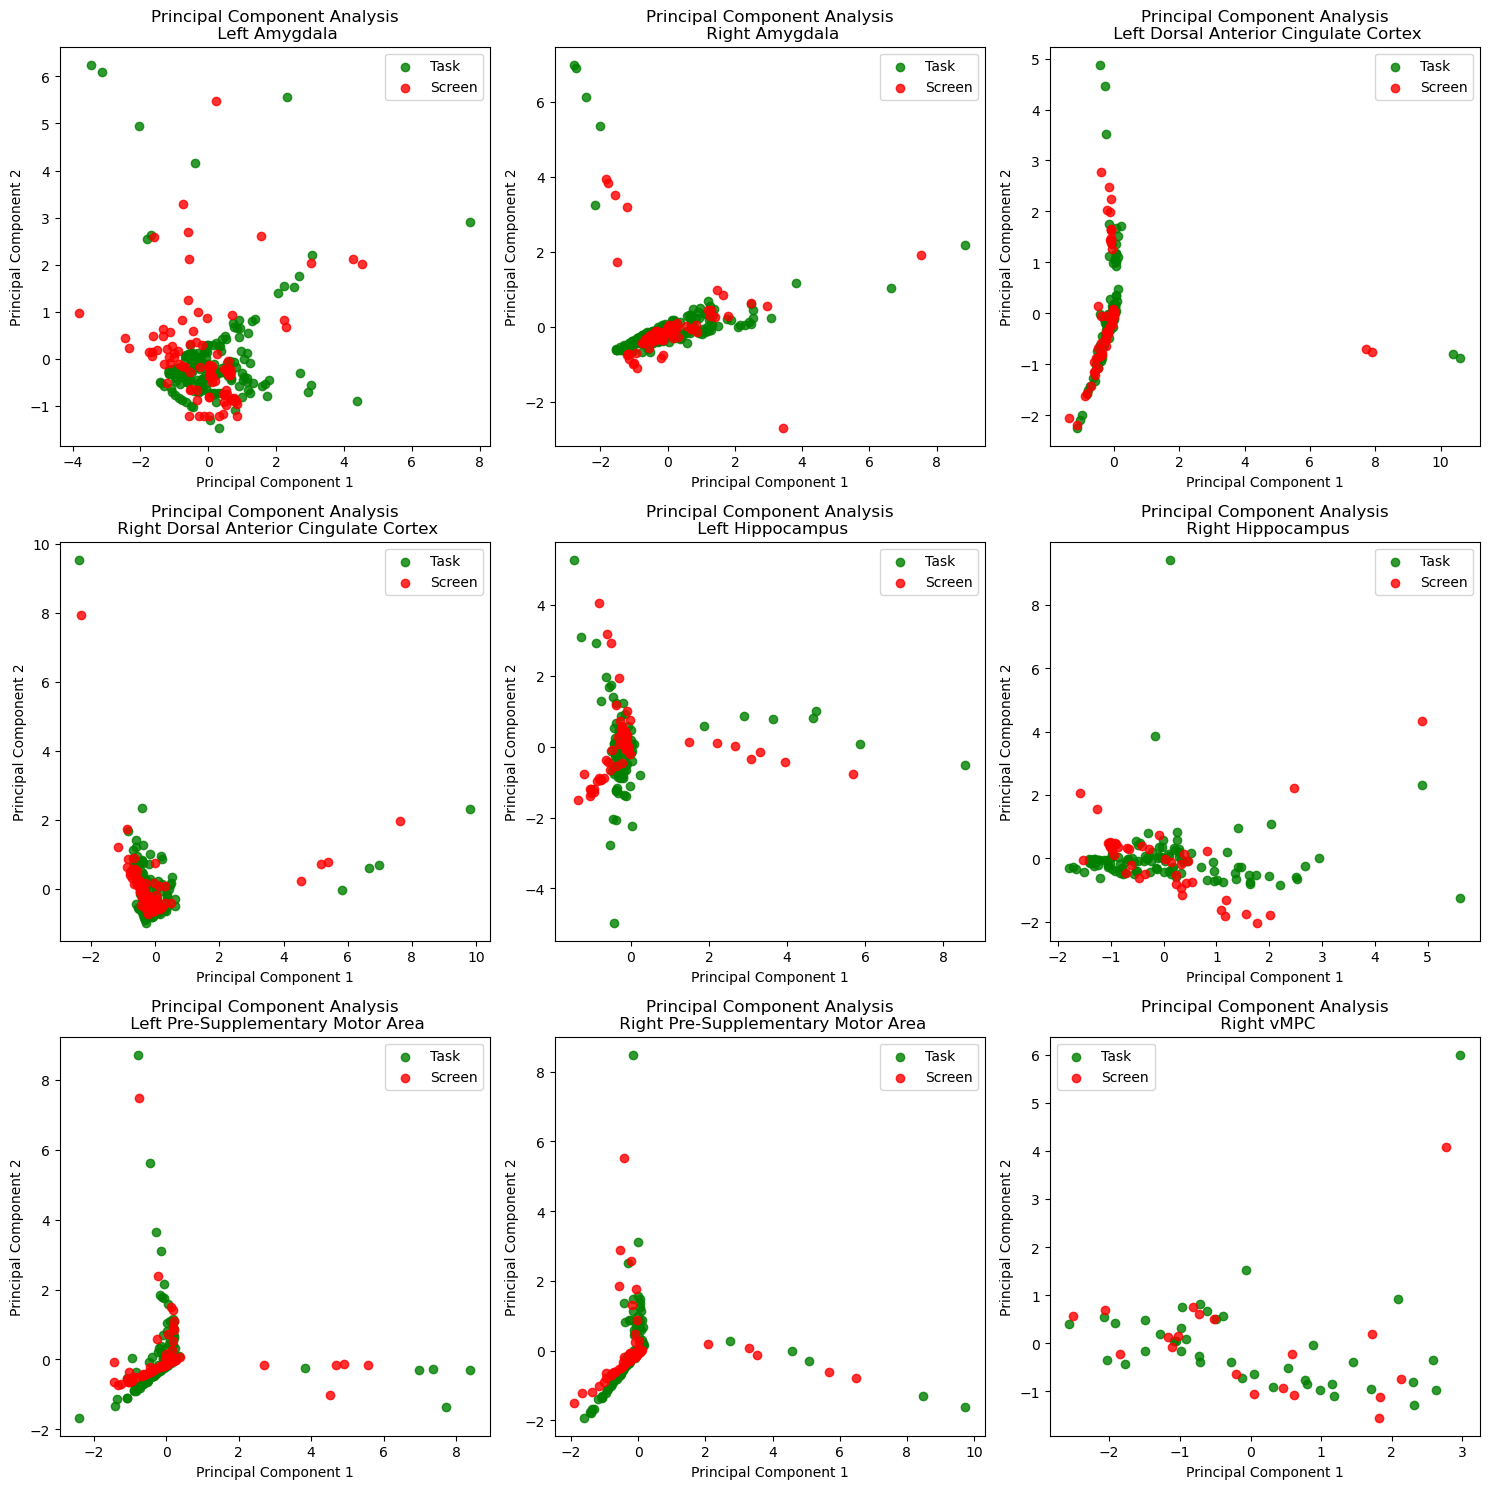

In [43]:
# Create a 9-plot figure to house all of the brain areas. 
fig1 = plt.figure(figsize = (15, 15))

# Iterate through the brain areas- there are 9 of them excluding the vMPC. 
for i in range(9): 
    
    ## First do cross-subject brain area analysis on the task data ##
    pca_data_task = brain_area_data_task_exclude_vMPC[i][features].dropna()
    
    # Reshaping is sometimes needed in PCA, but was not necessary in this case. 
    # pca_data = pca_data.reshape(1, -1)
    
    pca_data_task = StandardScaler().fit_transform(pca_data_task) 
    
    ## Debug to ensure that the data was correctly normalized. 
    # print(np.mean(pca_data), np.std(pca_data))

    pca_brainarea_task = PCA(n_components=2)
    PCA_brainarea_task = pca_brainarea_task.fit_transform(pca_data_task)

    # Plot the transformed task data
    plt.subplot(3, 3, i + 1)
    plt.scatter(PCA_brainarea_task[:, 0], PCA_brainarea_task[:, 1], alpha=0.8, color = 'g', label = 'Task')
    
    
    ## Now, the same transformation will be done on the screen data, and it will be plotted onto the same graph. 
    pca_data_screen = brain_area_data_screen_exclude_vPMC[i][features].dropna()
    # pca_data = pca_data.reshape(1, -1)
    pca_data_screen = StandardScaler().fit_transform(pca_data_screen) 
    
    ## Debug to ensure that the data was correctly normalized. 
    # print(np.mean(pca_data), np.std(pca_data))

    pca_brainarea_screen = PCA(n_components=2)
    PCA_brainarea_screen = pca_brainarea_screen.fit_transform(pca_data_screen)

    plt.subplot(3, 3, i + 1)
    plt.scatter(PCA_brainarea_screen[:, 0], PCA_brainarea_screen[:, 1], alpha=0.8, color = 'r', label = 'Screen')

    plt.title('Principal Component Analysis' + '\n ' + brain_areas_plaintext_exclude_vMPC[i])
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    
    plt.legend()
    
plt.tight_layout()
plt.show()

**Figure 1. PCA analysis of all recorded units within a given brain area, separated between the screen recording sessions (red) and task recording sessions (green).**

Visual inspection indicates that there are no notable changes in the shape of the distributions of units in any brain area between the screen and the task. However, seemingly non-random associations of units can be seen in all brain areas (though the Right vMPC may not have enough plotted units to conclude this based on visual inspection alone). 

Strongly isolated units can been seen in all brain areas (particularly so in the left dorsal ACC), which can be indicative of a spiking neuron or neuronal population that is strongly involved in both the screen and working memory task. 

Since the spatial distrubtuon by brain area is largely unchanged between the screen and the task, the succeeding KDE visualizations will only work with data from the task recording session (in which the actual Sternberg Working Memory task was performed).

In [44]:
# Save the figure
fig1.savefig('figure 1')

**Techniques used in this portion of the project:**
- sklearn PCA analysis
- numpy is integral to sklearn analysis
- np.mean and .std in the debug statements
- plt scatterplots visualization, two scatterplots with differential colors

## 3C) KDE plots of isolation distances by brain regions, across subjects, show signficant amounts of noise in the task dataset. 

The objective of this analysis is to elucidate the levels of noise in the dataset by plotting the distribution of isolation distances by brain region, across all subjects, in the task sessions. By plotting across brain regions across subjects rather than by subjects, regions with consistently high or low noise levels may be identified. 


Wile high isolation distances typically correspond to well-separated clusters or distinct populations within the dataset, low isolation distances signify that the units are closer to each other, which could imply higher levels of noise, overlap, or less discriminatory features within the data.  

Using seaborns, the histogram of isolation distances by brain area in the task sessions will be plotted, with a KDE curve fitted over top. Kernel Density Estimation (KDE) analysis is a method used to estimate the probability density function of a random variable based on a set of observations. 

By visualing the distribution of isolation distances along with the KDE curve, the noisiness within the dataset can be examined. 

Using the seaborn package, the KED curve is fit over the histogram of isolation distances by brain area. 

> The following tutorial was used to perform this analysis: (Python Graph Gallery) *Basic histogram with Seaborn.*

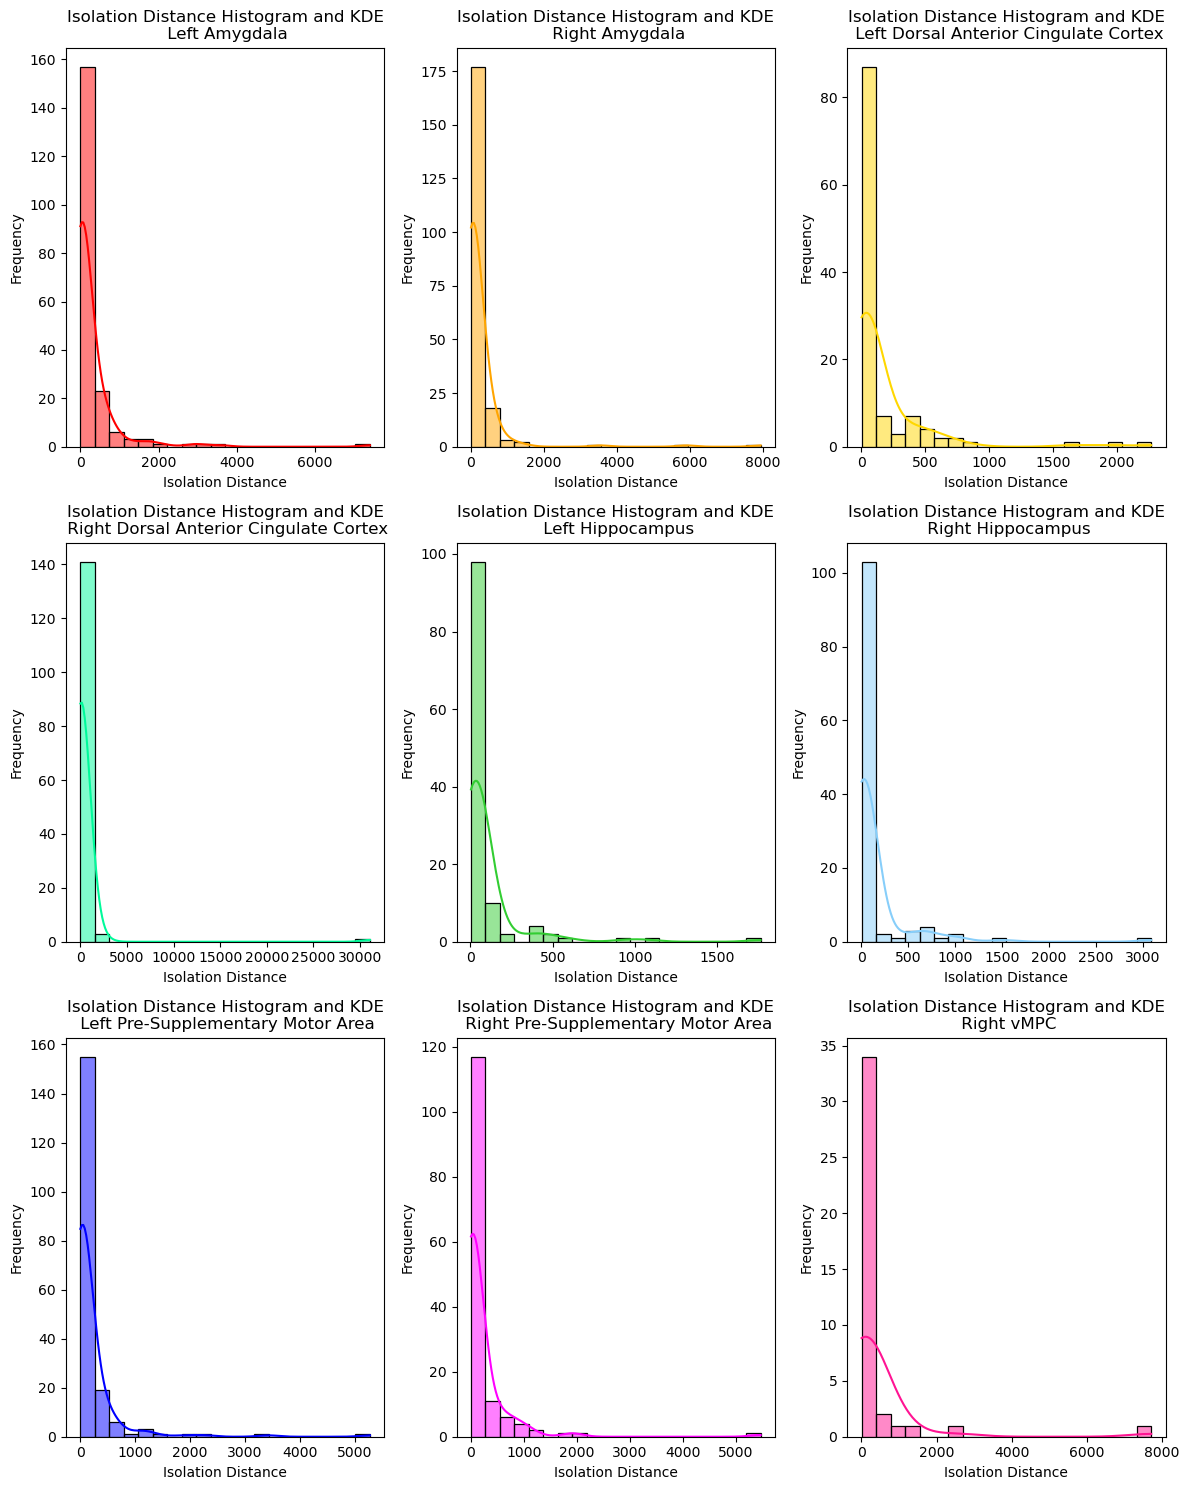

In [84]:
# import seaborn
import seaborn as sns

fig2 = plt.figure(figsize=(12, 15))

for i in range(9): # len(brain_areas_exclude_vMPC) = 9. In this loop, we are iterating over all brain areas that contain enough isolation distnace data. 
    data = brain_area_data_task_exclude_vMPC[i]['waveforms_isolation_distance'].dropna() # Drop the null values
    
    plt.subplot(3, 3, i + 1)
    
    # This is the actual seaborns plot
    sns.histplot(data, bins = 20, kde = True, color = brain_colors_exclude_vMPC[i])
    plt.subplots_adjust(hspace = 0.5)
    
    # Various figure features
    plt.title('Isolation Distance Histogram and KDE' + '\n ' + brain_areas_plaintext_exclude_vMPC[i])
    plt.xlabel('Isolation Distance') 
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Figure 2. Histograms of isolation distance with a fit KDE density curve, plotted by brain area using the seaborn package, with brain area data aggregated over all task trials for all subjects in the study**. Subject 19 excluded, as aforementioned. Data from the Left vMPC was insufficient in number to plot. Isolation distance was calculated in a *'ten-dimensional feature space (energy, peak amplitude, total area under the waveform, and the first five principal components of the energy normalized waveforms'*. Units along the axis are therefore a dimension of the feature space, and indecipherable at this level of analysis. 

Disproportionately high frequencies on the histogram are seen across all brain areas at low isolation distances, indicative of a significant level of background noise among the data of each brain region. KDE curve indicates an extremely low probably of detecing a unit at an isolation distance past the level of noise (which generally extends to around isolation distance = 2000) among all brain areas. However, some strongly isolated peaks can still be seen, especially in the right vMPC, dorsal ACC, and amygdala. 

In [46]:
# Save the figure
fig2.savefig('figure 2')

**Techniques used in this section of the project:**
- Use of seaborns package for statistical fitting and visualization
- Seaborns is integrated on top of matplotlib

## 3D) Correlation analysis of Peak SNR and Mean SNR across sessions on a by-subject, by-brain-area basis shows select sessions with brain regions showing likely reliable activity. 

A strong positive correlation between peak SNR and mean SNR for recording session indicates that units in that session with a high peak SNR generally also display high mean SNR. This correlation could potentially indicate genuine neural activity rather than noise or poor sorting, which is generally indicated by low peak and mean SNR. 

This analysis will establish a 'reliable' recording session for a given brain area as one that shows a strong postive correlation between Peak SNR and Mean SNR for units in that brain area. By correlating Peak SNR and Mean SNR in a brain-area specific, session specific manner, reliable recording sessions can be identified.  

First, a **'correlation matrix'** will be created. In a traditional correlation matrix, each cell contains the value for the correlation between its row and column index.  

In **this matrix**, the session ID (indicated by subject ID and screen or task) will be indicated on the row and the brain region on the column. Each cell will be populated by the correlation between Peak SNR and Mean SNR for that session's recording of that particular brain region. A **reliable session** for a certain brain region will be defined as session where the Peak/Mean SNR correlation is greater than 0.85 (arbitrarily chosen threshold). 

Cells in which correlations cannot be calculated (insufficient n) or no data is available will be populated by NaN. 

**<code>by_area_subj_corr_matrix</code> is the DataFrame that will eventually become the 'correlation' matrix is initalized here. This matrix is the central component of the analysis in this section.**

In [47]:
# The data_names list intially created as an index for the subject_data master series will be converted into a series
# Then into a Pandas DataFrame
# Upon conversion into a DataFrame, it will form the first column. 
by_area_subj_corr_matrix = pd.Series(data_names, name = "session_id").to_frame() 
# This 'correlation matrix' is going to store our correlation data. 

# Columns are then corresponding to every brain area
# Recall the brain_areas Series
for location in brain_areas.unique():
    by_area_subj_corr_matrix[location] = np.nan

If desired, inspect the empty matrix by un-commenting  the cell below. 

In [48]:
# by_area_subj_corr_matrix

Extracting the number of reliable sessions further lends the question as to what percentage of the total recording sessions are reliable ones. In order to calculate this metric, the total number of recording sessions in which a given brain region was recorded must be accounted for. 

In [49]:
# Total sessions is a series that stores the total number of recording sessions for each brain areas, with the index 
# set using the brain_areas series. 

total_sessions = pd.Series([0] * len(brain_areas), index = brain_areas.values)

Now, the matrix will be populated with the following nested for loop. 

Note that, for statisical strictness, correlations will only be calculated if the number of units recorded for a given brain region in the session was at least 10. 

In [50]:
# For each index in the subject_data master series = each session. 
for index in range(len(subject_data)):
    session_id_copy = subject_data[index].copy()  # Make a copy of the particular session id that is being used to avoid modifying the original. 
    
    ## DEBUG STATEMENT: Ensure correct copying
    # print(session_id_copy)
    
    # For each integer area index in brain_areas
    # Need to use this integer index in order to make a local 'area' object, which is essential for manipulating the total_sessions
    # And also for populating the matrix later
    for area_index in range(len(brain_areas)): 
        
        area = brain_areas[area_index] # Extract the area. 
        ## DEBUG STATEMENT: Print the area to ea
        # print(area)
        
        # Check if that brain area is in the matrix more than ten times, and if it is, calculate the correlation
        if ((session_id_copy['location'] == area).sum() > 10):
            # First add a count to the total_sessions series; we're merely keeping track of how many times that brain area was recorded
            total_sessions.loc[area] += 1
            
            # Calculate the correlation by first masking the relevant rows in each DataFrame
            # Only some of the rows in the dataframe correspond to the location you want
            by_loc_peak_snr_mask = session_id_copy[session_id_copy['location'] == area]['waveforms_peak_snr']
            by_loc_mean_snr_mask = session_id_copy[session_id_copy['location'] == area]['waveforms_mean_snr']
            # Then calculate the correlation
            correlation = by_loc_peak_snr_mask.corr(by_loc_mean_snr_mask)
            
            # Add correlation to the matrix by replacing the specified value
            by_area_subj_corr_matrix.iloc[index, area_index + 1] = correlation
        
        # Even if it is not in the matrix more then 10 times, add it to the count for total recording sessions
        elif ((session_id_copy['location'] == area).sum() > 0):
            # Increase the count anyways
            total_sessions.loc[area] += 1
            
            ## DEBUGGING STATEMENT: Making sure it's adding correctly
            ## print(area_index)

In [51]:
# For some reason, our code both appended rows and replaced values. 
# I'll simply drop the last 9 columns (there are 9 brain areas).

# by_area_subj_corr_matrix = by_area_subj_corr_matrix.iloc[:, :-9]

# This is actually not true and probably had something to do with initilizaton issues, 
# but it was a great display of slicing with negative indexing when it worked, so I will leave it. 

After running the nested for loop, the matrix is as populated. For each session/brain region pair, if there were at least 10 recorded units in the session for that brain region, the correlation was calculated and populated into the cell. If desired, run the following cell to show the matrix. 

In [52]:
# by_area_subj_corr_matrix 

Using .describe() shows us some important metrics about this dataset. 
- <code> ventral_medial_prefrontal_cortex_left </code> had no correlations. 
- Taking the left amygdala as an example: 
    - There were 7 sessions where units = n > 10 for the left amygdala. Note that this does **not** correspond to a reliable session. 
    - The quartile summary shows that the correlations were generally very strong (median = 0.974933). 
    - However, the min was -0.616491. 
    
- Many brain areas show a low minimum correlation, indicating that this matrix needs to be further processes to extract the 'reliable sessions.'

In [53]:
by_area_subj_corr_matrix.describe()

,amygdala_left,amygdala_right,dorsal_anterior_cingulate_cortex_left,dorsal_anterior_cingulate_cortex_right,hippocampus_left,hippocampus_right,pre_supplementary_motor_area_left,pre_supplementary_motor_area_right,ventral_medial_prefrontal_cortex_left,ventral_medial_prefrontal_cortex_right
count,7.000000,10.000000,5.000000,9.000000,6.000000,5.000000,10.000000,9.000000,0.0,3.000000
mean,0.724649,0.973067,0.820576,0.913872,0.945917,0.934988,0.960381,0.923597,NaN,0.915168
std,0.593972,0.017838,0.308142,0.109660,0.041831,0.095245,0.026947,0.084557,NaN,0.040617
min,-0.616491,0.930890,0.270963,0.651831,0.885781,0.766752,0.901675,0.732143,NaN,0.889198
25%,0.882640,0.973635,0.921455,0.920788,0.915013,0.962211,0.949583,0.884876,NaN,0.891765
50%,0.974933,0.976229,0.955682,0.963121,0.963975,0.962470,0.962693,0.961376,NaN,0.894333
75%,0.981453,0.981788,0.969671,0.974969,0.977321,0.987126,0.979446,0.973143,NaN,0.928154
max,0.985911,0.992323,0.985111,0.988845,0.981311,0.996379,0.994208,0.991773,NaN,0.961975


Using an arbitrary threshold of a correlation above 0.85:
- any correlation below that threshold will be made an NaN. 
- *any correlation above that threshold will be deemed a 'reliable session' for that brain area.* 

In [54]:
# Mask: every cell in the matrix > 0.85
strong_corr_mask = (by_area_subj_corr_matrix.iloc[:, 1:] > 0.85) # We need to exclude the first column- that's the session ID. 

# Convert anything that is not that into an np.nan
by_area_subj_corr_matrix[~strong_corr_mask] = np.nan

# Un-comment this to return if desired. 
#by_area_subj_corr_matrix

In [55]:
# Some sessions were NaN across all of the brain areas. 
# We can also drop these sessions that had no reasonable correlations. 
corr_matrix_condensed = by_area_subj_corr_matrix.dropna(how = 'all', subset=by_area_subj_corr_matrix.columns[1:])

# corr_matrix.reset_index(drop=True)

# Un-comment this to return if desired. 
#corr_matrix_condensed

<code>corr_matrix_condensed</code> includes only those sessions that provided some reliable information. 

By using df.shape() to inspect its rows and columns, we find that out of 40 sessions, only 28 show likely reliable activity. 

In [56]:
# Use df.shape() to find the number of rows and columns in the correlation matrix. 
corr_rows, corr_columns = corr_matrix_condensed.shape
print(corr_rows)

28


Using extensive correlation analysis, the number of sessions that can be considered to be a 'reliable session' for at least one brain area has been determined to be 28. 

**Techniques used in this section of the project:**
 - NumPy aggregate functions
 - slicing and masking
 - .describe() and .shape to exract important features

### 3d.a) Visualize the number of reliable sessions versus total sessions for each brain region. 
In asking the question of how many reliable recording sessions are in the dataset, the question of *"What percentage of the recording sessions can be considered 'reliable?'* is also implicit.  

Using two series, one containing the total number of sessions by brain region and one containing the number of reliable sessions by brain region, the percentage of reliable sessions by brain region can be calculated and visualized. 

Iterating through a Series is personally preferable to element-wise numpy array operations here due to the preservation of brain region labels. 

This analysis provides an additonal metric for analyzing the quality of the dataset. For example, significantly low percentages may indicate low quality signals in a particular brain area, or a particularly inactive region of the brain during this task. 

In [57]:
# Let's make a series where we can store the number of reliable sessions for each brain area. 
reliable_sessions = pd.Series(index = brain_areas.values)

for i in range(len(brain_areas)): 
    # reliable_session for a given brain area = count the number of non null values in that column of the correlation matrix
    reliable_sessions[brain_areas[i]] = by_area_subj_corr_matrix[brain_areas[i]].count()
    
reliable_sessions

amygdala_left                              5.0
amygdala_right                            10.0
dorsal_anterior_cingulate_cortex_left      4.0
dorsal_anterior_cingulate_cortex_right     7.0
hippocampus_left                           6.0
hippocampus_right                          4.0
pre_supplementary_motor_area_left         10.0
pre_supplementary_motor_area_right         8.0
ventral_medial_prefrontal_cortex_left      0.0
ventral_medial_prefrontal_cortex_right     3.0
dtype: float64

In [58]:
# And the total recording sessions
total_sessions

amygdala_left                             24
amygdala_right                            31
dorsal_anterior_cingulate_cortex_left     26
dorsal_anterior_cingulate_cortex_right    23
hippocampus_left                          24
hippocampus_right                         21
pre_supplementary_motor_area_left         23
pre_supplementary_motor_area_right        24
ventral_medial_prefrontal_cortex_left      2
ventral_medial_prefrontal_cortex_right     7
dtype: int64

In [59]:
# Calculating the percentages and round to 2 decimal places
session_percent = np.divide(reliable_sessions.values, total_sessions)*100
session_percent = session_percent.round(2)

A barplot can easily visualize this relationship.

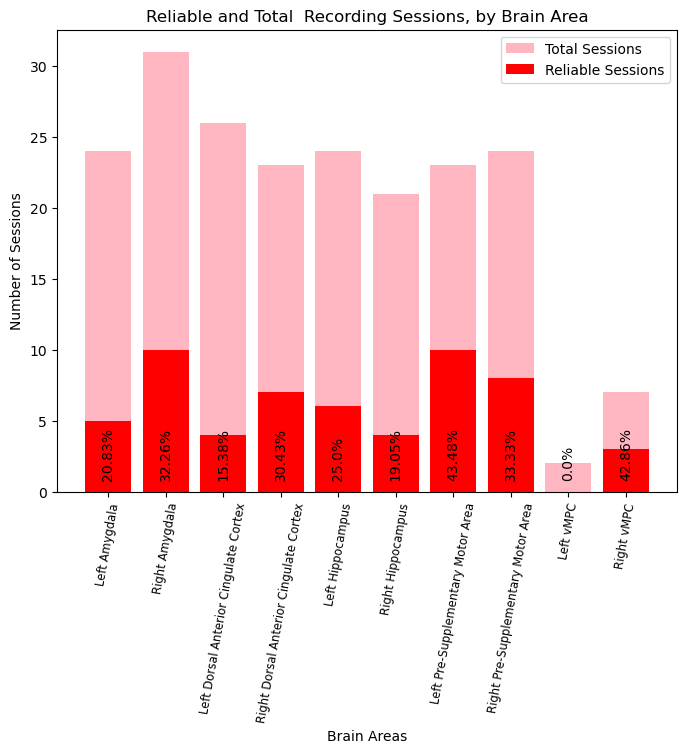

In [60]:
# Create a figure. Only using one subplot. 
fig3 = plt.figure(figsize=(8, 6))

# Add both bar plots
plt.bar(brain_areas_plaintext, total_sessions.values, color = 'lightpink', label = 'Total Sessions')
plt.bar(brain_areas_plaintext, reliable_sessions.values, color = 'red', label = 'Reliable Sessions')

# Add relevant figure features
plt.xlabel('Brain Areas')
plt.ylabel('Number of Sessions')
plt.title('Reliable and Total  Recording Sessions, by Brain Area')
labels = plt.xticks(brain_areas_plaintext,
                    rotation = 80, 
                    fontsize = 'small')


# Add percentages as text to the bar graph denoting what percent of recording sessions may be reliable
for index, value in enumerate(session_percent):
    plt.text(index, 1, str(value) + '%', ha='center', rotation = 90, color = 'black')
    
plt.legend()
plt.show()

**Figure 3. Bar plot of reliable and total recording sessions, by brain area.** Percentages of reliable sessions over total written on the bar plot in black. Other than the left vMPC, which contained no reliable units (likely due to a small n), percentages generally fell between the 20-40% range. Inspecting of the quality of the dataset by this metric indicates that the quality of neural recordings is generally good- there is a signifcant percentage of 'reliable sessions' in each brain area. 

In [61]:
# Save the figure
fig3.savefig('figure 3')

## 3E) Filtering highly-responsive units using Peak SNR thresholds and Mean SNR thresholds identifies possible significant units. 

Here, after identifying 'reliable' recording sessions, basic threshold analysis using both Mean and Peak SNR in the identified may be used to extract any significant units. 

Threshold analysis is a basic statistical technique in which a threshold value for a dataset (usually based on mean and standard deviation) is established in order to dilineate abnormal datapoints. 

The following thresholds will be established in this analysis: 
- Units with peak SNR greater than 3 standard deviations above the mean peak SNR for a given location in a given recording session will be considered signicant in terms of peak SNR
- Units with mean SNR greater than 3 standard deviations above the mean mean SNR for a given location in a given recording session will be considered signicant in terms of mean SNR

Using this technique, significant units with respect to peak SNR and mean SNR can be identified. The most robust units, corresponding to will likely be significant with respect to both. 

In this analysis, any unit that exceeds either a Peak SNR threshold or a Mean SNR threshold will be considered a potential high-response cell, worthy of further investigation. It is also important to note that this analysis will only be conducted in sessions previously having been identified as "reliable."

First, functions to establish both: 
1) threshold values and 
2) how many values in the session exceed this threshold 

by both mean and peak will be defined. 

The threshold-finding functions pass through the session data, and return the (1) threshold value based on the specified parameter and the (2) number of values in the DataFrame that exceed it. The functions are identical except for the columns that they call: <code>waveforms_mean_snr</code> vs. <code>waveforms_peak_snr</code>. Also note that they have two return statements. 

In [62]:
# Function to establish the threshold by mean SNR

def mean_SNR_thresh(session_data):
    # First want to exclude outliers in the mean and standard deviation calculation- otherwise nothing is above the threshold
    
    # Calculate the IQR. This uses NumPy
    q1 = np.percentile(session_data['waveforms_mean_snr'], 25)
    q3 = np.percentile(session_data['waveforms_mean_snr'], 75)
    iqr = q3 - q1
    
    # Calculate the bound for the lower outlier and the upper outlier
    lower_outlier = q1 - 1.5*iqr
    upper_outlier = q3 + 1.5*iqr
    
    # Exclude outliers
    no_outliers = session_data[(session_data['waveforms_mean_snr'] >= lower_outlier) & (session_data['waveforms_mean_snr'] <= upper_outlier)]
   
    # Calcuate the mean and standard deviation of the mean_snr while excluding outliers 
    mean_SNR_stdev = no_outliers['waveforms_mean_snr'].std()
    mean_SNR_mean = no_outliers['waveforms_mean_snr'].mean()
    
    # Calculate the threshold for a unit. In this case, we're using 3 standard deviations
    meanSNR_thresh = mean_SNR_mean + 3*mean_SNR_stdev
    
    # Mask the number of values above the threshold
    above_thresh = session_data['waveforms_mean_snr'] > meanSNR_thresh

    # Count the number above the threshold: 
    num_above_threshold = above_thresh.sum()
    
    return meanSNR_thresh, num_above_threshold

In [63]:
# This function is identical to above, but with peak SNR. 

def peak_SNR_thresh(session_data):
    # First want to exclude outliers in the mean and standard deviation calculation- otherwise nothing is above the threshold
    
    # Median
    peak_SNR_median = session_data['waveforms_peak_snr'].median()
    
    # Calculate the IQR. This uses NumPy
    q1 = np.percentile(session_data['waveforms_peak_snr'], 25)
    q3 = np.percentile(session_data['waveforms_peak_snr'], 75)
    iqr = q3 - q1
    
    # Calculate the bound for the lower outlier and the upper outlier
    lower_outlier = q1 - 1.5*iqr
    upper_outlier = q3 + 1.5*iqr
    
    # Exclude outliers
    no_outliers = session_data[(session_data['waveforms_peak_snr'] >= lower_outlier) & (session_data['waveforms_peak_snr'] <= upper_outlier)]
    
    # Calcuate the mean and standard deviation of the peak_snr
    peak_SNR_stdev = no_outliers['waveforms_peak_snr'].std()
    peak_SNR_mean = no_outliers['waveforms_peak_snr'].mean()
    
    # Calculate the threshold for a unit, in this case we're using 3 standard deviations
    peakSNR_thresh = peak_SNR_mean + 3*peak_SNR_stdev
    
    # Mask the number of values above the threshold
    above_thresh = session_data['waveforms_peak_snr'] > peakSNR_thresh #Want to use the original data for this
    
    ## DEBUGGING STATEMENT: Print out the mask
    # print(session_data[above_thresh])
    
    # Count the number above the threshold: 
    num_above_threshold = above_thresh.sum()
    
    return peakSNR_thresh, num_above_threshold

The functions have now been created. 

Now, a DataFrame will be populated based on the following information: 
- The **session_id:** in terms of subject number, and task or screen
- The **location** of the electrode
- The **mean SNR threshold** value
- The **number of units above the mean SNR threshold**
- The **peak SNR threshold** value
- The **number of units above the peak SNR threshold**

In [64]:
# Create a dataframe to store the data according the parameters previously listed. 

# This is a list of the column names to be used. This list itself will not be used. 
units_df_names =  ['session_id', 'location', 'mean_thresh', 'num_above_thresh_mean', 'peak_thresh', 'num_above_thresh_peak']

In [65]:
notable_units_df_rows = [] # Initialize a list that will hold all of the rows of our eventual  dataFrame. 

for index, row in by_area_subj_corr_matrix.iterrows():
    session_data = subject_data[index]
    
    ## DEBUGGING STATEMENT
    #print(session_data)
    
    for col_num, value in enumerate(row.iloc[1:], start=1): # Start at 
        
        if not pd.isnull(value):  # Check if the value is not NaN, and if not
            
            # Create a new row that will be appended to notable_units_df
            new_unit = {} # This is a dictionary that will eventually become a row
            
            # Adding session_id and location to the new row
            new_unit['session_id'] = by_area_subj_corr_matrix['session_id'][index]
            new_unit['location'] = brain_areas[col_num - 1] # Need to subtract 1 because the first column is the session ID
            
            # Mask the session data to extract only those rows pertaining to the columns we want
            loc_mask = session_data['location'] == brain_areas[col_num - 1]
            relevant_data = session_data[loc_mask]
            
            # Save the outputs of the threshold functions to two variables
            meanSNR_thresh, num_above_mean = mean_SNR_thresh(relevant_data)
            peakSNR_thresh, num_above_peak = peak_SNR_thresh(relevant_data)
              
            # Assiign these variables to items in the dict
            new_unit['mean_thresh'] = meanSNR_thresh
            new_unit['num_above_thresh_mean'] = num_above_mean
            new_unit['peak_thresh'] = peakSNR_thresh
            new_unit['num_above_thresh_peak'] = num_above_peak
            
            # DEBUG STATEMENT
            # print(new_unit)
        
            # Append the new unit to the rows list
            notable_units_df_rows.append(new_unit)

From the list of dictionaries, <code>the notable_units_df</code> is created. <code>notable_units_df</code> is the central structure in this portion of the analysis, and allows for the identification of sessions with many potentially high-response units. 

In [66]:
notable_units_df = pd.DataFrame(notable_units_df_rows)
notable_units_df.head()

,session_id,location,mean_thresh,num_above_thresh_mean,peak_thresh,num_above_thresh_peak
0,subj10_screen,amygdala_right,1.354538,1,6.471692,1
1,subj10_screen,hippocampus_left,1.279486,1,7.033649,0
2,subj10_screen,pre_supplementary_motor_area_left,4.092266,0,15.044961,0
3,subj10_task,pre_supplementary_motor_area_left,3.586121,0,13.087623,0
4,subj11_screen,amygdala_left,1.584117,2,6.877309,1


The number of units that are above the mean SNR threshold for their respective recording sessions can be elucidated using <code>.sum()</code>. 

In [67]:
notable_units_df['num_above_thresh_mean'].sum()

46

Likewise for the peak SNR threshold: 

In [68]:
notable_units_df['num_above_thresh_peak'].sum()

55

From visually inspecting the <code>notable_units_df</code> DataFrame, two sessions can be identified as having the most number of significant units with respect to either Peak SNR or Mean SNR. 

In [69]:
# Use fancy indexing to display these values
notable_units_df.iloc[[10, 44]]

,session_id,location,mean_thresh,num_above_thresh_mean,peak_thresh,num_above_thresh_peak
10,subj11_task,pre_supplementary_motor_area_left,2.907538,2,8.617833,5
44,subj7_task,amygdala_right,1.318573,3,5.796031,3


The <code>notable_units_df</code> is therefore very useful for summarizing which sessions contain the greatest number of significant units and where, as well as where the significant units are located in general. 

Threshold levels plotted onto a scatterplot of Peak SNR vs. Mean SNR  will can be used to visualize this significance. As a sample, <code>notable_units_df</code> rows 10 and 44, as well as 41 (arbitrarily chosen) will be visualized. 

In [70]:
# Use fancy indexing to display the values that will be plotted
notable_units_df.iloc[[10, 41, 44]]

,session_id,location,mean_thresh,num_above_thresh_mean,peak_thresh,num_above_thresh_peak
10,subj11_task,pre_supplementary_motor_area_left,2.907538,2,8.617833,5
41,subj6_task,pre_supplementary_motor_area_left,3.643233,2,13.376800,3
44,subj7_task,amygdala_right,1.318573,3,5.796031,3


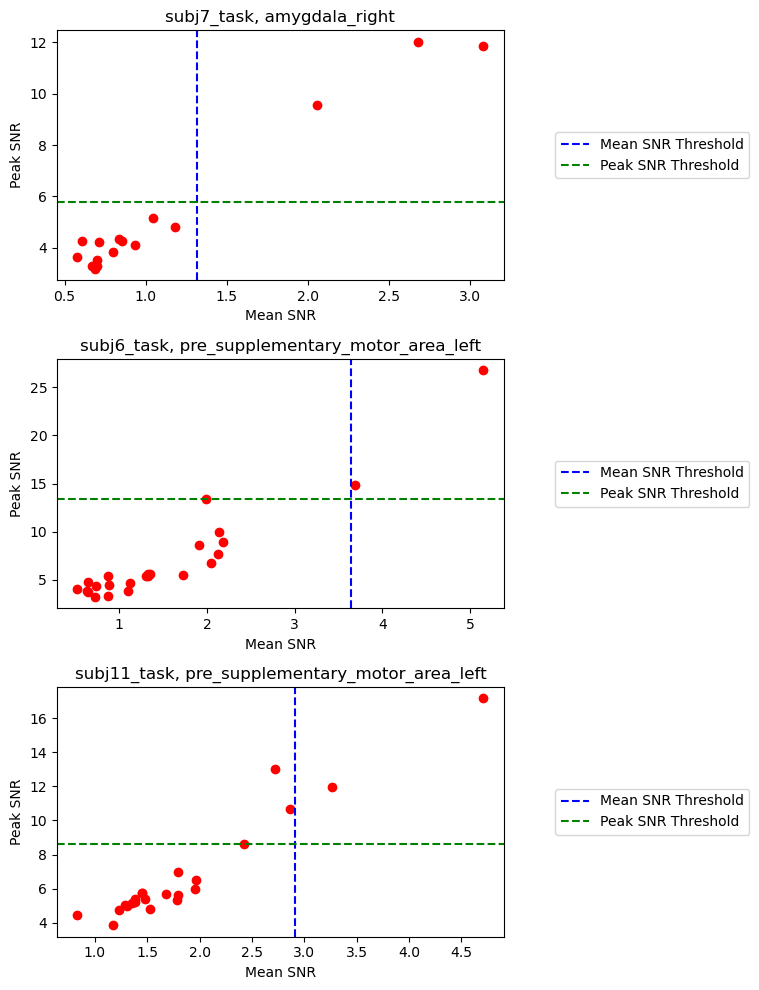

In [82]:
fig4 = plt.figure(figsize = (8, 10))
plt.subplots_adjust(hspace=0.5)

def add_subplot(session_id, location, i, mean_thresh, peak_thresh): 
    subplot = plt.subplot(3, 1, i)
    
    # Mask out the location rows and extract the peak and mean using it, as the y and x
    loc_mask1 = subject_data.loc[session_id]['location'] == location
    x = subject_data.loc[session_id][loc_mask1]['waveforms_mean_snr']
    y = subject_data.loc[session_id][loc_mask1]['waveforms_peak_snr']
                                        
    # DEBUGGING STATEMENT
    # loc_only = subject_data.loc['subj7_task'][loc_mask]
    
    # Plotting the scatter
    subplot.scatter(x, y, color = 'r')

    # Adding the threshold lines
    subplot.axvline(x=mean_thresh, color = 'b', linestyle = '--', label = 'Mean SNR Threshold')
    subplot.axhline(y=peak_thresh, color = 'g', linestyle = '--', label = 'Peak SNR Threshold')
    
    # Adding title, legend, and x/y labels
    subplot.set_title(session_id + ", " + location)
    subplot.legend(loc = 'center left', bbox_to_anchor = (1.10, 0.5))
    subplot.set_xlabel('Mean SNR')
    subplot.set_ylabel('Peak SNR')
    
# Add the subplots
add_subplot('subj7_task', 'amygdala_right', 1, 1.318573, 5.796031)
add_subplot('subj6_task', 'pre_supplementary_motor_area_left', 2, 3.643233, 13.3768)
add_subplot('subj11_task', 'pre_supplementary_motor_area_left', 3, 2.907538, 8.617833)

plt.tight_layout()
plt.show()

**Figure 4. Scatterplot of Peak SNR vs. Mean SNR for 3 select sessions and brain regions. Mean SNR and Peak SNR thresholds denoted on the plot.**
All three sessions show an extremely strong postive correlation between Peak SNR and Mean SNR. For Subject 7, right amygdala and Subject 6, left pre-supplementary motor area, units above the Peak SNR threshold were also above the Mean SNR threshold, though this was not true for Subject 11, left pre-supplementary motor area. Units above both thresholds could potentially indicate greater significance. 

As visually indicated by these plots, for these three recording sessions within a given brain area, 2-3 units may potentially be significant, high-responding cells. Cells in the top-right portion of each graph,  as determined by the thresholds, should be filtered out for further analysis.  

In [72]:
# Save the figure
fig4.savefig('figure 4')

# 3F) Extraction and visualization of highly-responsive units using Mean SNR  threshold analysis

In the final section of the data analysis, using the <code>mean_SNR_thresh</code> function previously created and the xyz electrode locations included in the datafile, every highly-responsive unit during the task sessions, as determined by Mean SNR threshold analysis, will be mapped onto 3D space. Mean Threshold Analysis is used rather than Peak SNR, as Mean SNR is a more robust metric. 

Though the brain itself will not be visualized, visualization in 3D space will provide an illustrative depiction of where exactly the 'highly-responsive' units are localized in the brain. The different brain areas that each unit is located in to will be differentiated via color-coding. 

This portion of the data analysis aims to: 
- Extract all of the highly-responsive units across the task data as determined by Mean SNR threshold analysis
- Extract all of the highly-responsive units across the task data as determined by Peak SNR threshold analysis
- Visualize the Mean-SNR threshold analysis in 3D space

### Extraction of highly-responsive units. 
**First, in order to organize all of the 'highly-responsive' (hr) units, two new DataFrames will be created to organize all of the identified units.**

The <code>hrCells_byMean</code> and <code>hrCells_byPeak</code> dataframes will contain all of the same columns as any DataFrame in the <code>subject_data</code> master series, as they will merely contain the rows for every unit identified as highly responsive. Thus, the method used for 'duplicating' columns to create a new DataFrame is as follows: 

In [73]:
hrCells_byMean = pd.DataFrame(columns = subject_data[0].columns)
hrCells_byPeak = pd.DataFrame(columns = subject_data[0].columns)

# These lambda functions standardize the dtype as an object across the DataFrame, but this does not seem necessary. 
# hrCells_byMean = respondingCells_byMean.apply(lambda x: pd.Series(dtype='object'))
# hrCells_byPeak = respondingCells_byPeak.apply(lambda x: pd.Series(dtype='object'))

Now, loops will be run to pull out all of the relevant units. This loop and mask is almost identical to the method used to create <code>notable_units_df</code>, as it is merely going one step further to actually extract the above-threshold units. 

Importantly, this loop pulls out the Mean SNR threshold determined values and the Peak SNR threshold determined values concurrently. Then they are saved to a special DataFrame. 

In [74]:
# Do another loop, this time to pull out all of the relevant units 

for index, row in by_area_subj_corr_matrix.iterrows():
    
    session_data = subject_data[index]
    ## DEBUGGING STATEMENT
    # print(session_data)
    
    for col_num, value in enumerate(row.iloc[1:], start=1):
        if not pd.isnull(value):  # Check if the value is not NaN, and if not
            loc_mask = session_data['location'] == brain_areas[col_num - 1] # -1 because we exclude the first, so the index is shifted up by one
            relevant_data = session_data[loc_mask]
            
            # Run the functions, and save their only the first return (the threshold value)
            meanSNR_thresh = mean_SNR_thresh(relevant_data)[0]
            peakSNR_thresh = peak_SNR_thresh(relevant_data)[0]
            
            ## DEBUG STATEMENTS TO MAKE SURE WE'VE EXTRACTED THE VALUES CORRECTLY
            #print(mean_threshold_value)
            #print(peak_threshold_value)
            
            # Create a mask to extract the values above the waveform by the corresponding column
            above_thresh_peak = relevant_data['waveforms_peak_snr'] > peakSNR_thresh
            above_thresh_mean = relevant_data['waveforms_mean_snr'] > meanSNR_thresh
            
            # Extract the rows using the mask
            rows_above_thresh_peak = relevant_data[above_thresh_peak]
            rows_above_thresh_mean = relevant_data[above_thresh_mean]
            
            ## DEBUG STATEMENTS TO MAKE SURE WE'VE DONE EVERYTHING CORRECTLY
            #print(above_mean_thresh_mask)
            #print(relevant_data)
            #print(relevant_data[above_thresh_mean])

            # If the DataFrame is empty, add the data by copying. This technique has been used already in this project. 
            if hrCells_byMean is None or hrCells_byMean.empty:
                 hrCells_byMean = rows_above_thresh_mean.copy() # Copy the selected data and enter it in
            # Otherwise, concatenate the DataFrames. 
            else: 
                 hrCells_byMean = pd.concat([hrCells_byMean, rows_above_thresh_mean], ignore_index=True)
            
            # Same technique as above, but by Peak.
            if hrCells_byPeak is None or hrCells_byPeak.empty:
                 hrCells_byPeak = rows_above_thresh_peak.copy() # Copy the selected data and enter it in
            else: 
                 hrCells_byPeak = pd.concat([hrCells_byPeak, rows_above_thresh_peak], ignore_index=True)

In [83]:
# If we take a look at the DataFrame, we can see that it is filled with units.
# These units are directly taken from the data and populated to the special DataFrame. 
hrCells_byPeak.head()

,location,electrodes,clusterID_orig,waveforms_mean_snr,waveforms_peak_snr,waveforms_isolation_distance,waveforms_mean_proj_dist,x,y,z
0,amygdala_right,36,510,2.425993,10.742008,5895.237637,15.485633,19,-1.8,-15.9
1,amygdala_left,6,2334,1.761742,7.050660,25.139212,0.000000,-20,-1.7,-22
2,pre_supplementary_motor_area_left,14,1313,3.479818,12.176309,55.680008,20.996389,-6,18.3,43.9
3,pre_supplementary_motor_area_left,17,1676,2.964823,11.077042,66.170173,13.976082,-6,18.3,43.9
4,pre_supplementary_motor_area_left,18,1436,2.984856,10.496286,27.317481,21.010495,-6,18.3,43.9


To affirm that the highly-responsive units have been extracted properly, it can be confirmed that the number of rows in the <code>hrCells_byPeak</code> DataFrame is equal to the sum of the <code>num_above_thresh_peak</code> columm from the earlier <code>notable_units_df</code> DataFrame (and likewise for Mean SNR). 

In [76]:
# Get the number of rows and columns using df.shape()
rows_peak, cols_peak = hrCells_byPeak.shape
# Compare the number of rows to the number above the threshold value identified in previous analysis. 
rows_peak == notable_units_df['num_above_thresh_peak'].sum()

True

In [77]:
# Get the number of rows and columns
rows_mean, cols_mean = hrCells_byMean.shape
# Compare the number of rows to the number above the threshold value identified in previous analysis. 
rows_mean == notable_units_df['num_above_thresh_mean'].sum()

True

From this, it can be confidently said that the highly-responsive units have been properly extracted. 

**Techniques used in this portion of the project:**
 - Use of a dictionary to append new rows
 - df.shape() within a boolean comparison
 - masking
 - if else statements

### Visualizaton of highly-responsive units, as identified by Mean SNR threhold analysis, in 3D space. 

Now that the highly-responsive units have been properly extracted, a final 3D visualization will be helpful to visualize their 3D spatial distribution. 

Since the data on each unit contains coordinates along the x, y and z axis, a 3D visualization can be easily plotted. The locations of recording sites were superimposed by the authors onto the California Institute of Technology’s CIT168
T1w brain atlas, and expressed in MINI-coordinates (mm).  

Though no numerical analysis will be performed by or as a result of this visualization, it will be essential for presenting the results of previous numerical analysis (i.e., mean SNR threshold analysis) in a novel and effective way. 

The following tutorials and modules aided in this coding:
> The following tutorial was adapted for this visualization: (Python Programming) *3D Scatter Plot with Matplotlib.*

> Color map documentation was accessed here: (matplotlib) *Creating Colormaps in Matplotlib.*

> Documentation on zip, used in the color-mapping: (W3 Schools) *Python zip() Function.*

In [78]:
# Import Axes3D from plt
from mpl_toolkits.mplot3d import Axes3D

The 3D spatial visualizaton for each unit identified as a highly-responsive unit via Mean SNR Threshold analysis will be plotted. Recall that, through Mean SNR threshold analysis, 46 such units were identified: 

In [79]:
rows_mean # This value is from the df.shape call from earlier

46

The code for the plot is below. 

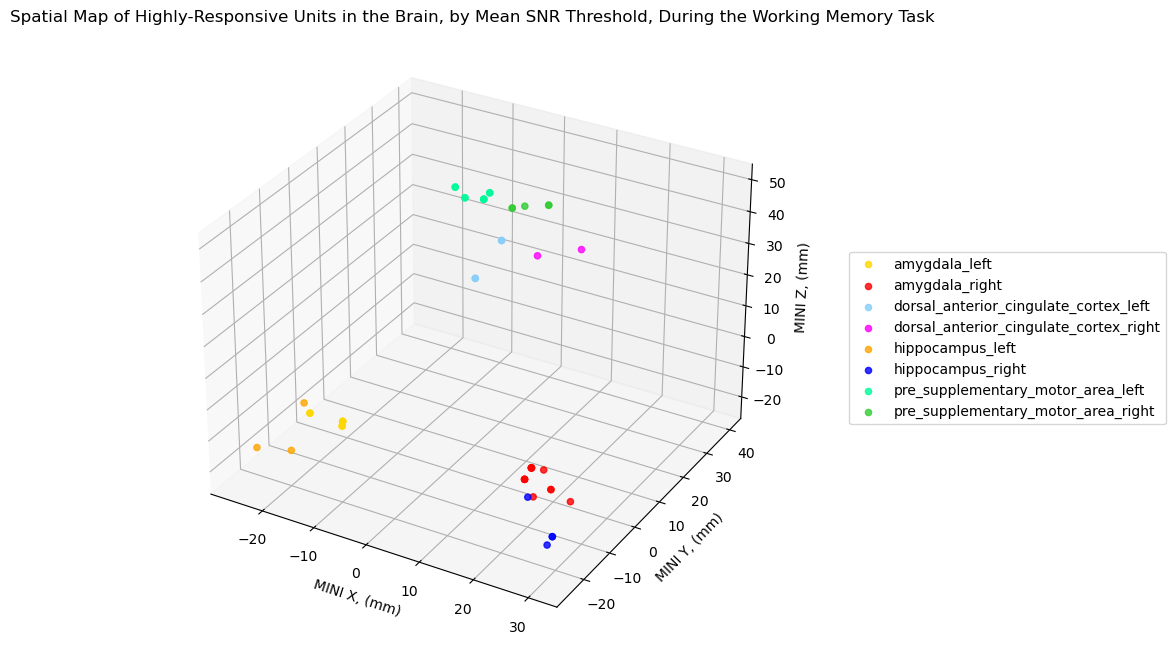

In [80]:
# Mean 3D is the mean SNR data as it will be adapted for 3D space. 
mean_3D = hrCells_byMean.dropna(subset=['waveforms_mean_snr']) # Some quick cleaning- there was an NaN at the end

# print(mean_3D['x'].dtype) # This print statement gives that x is saved as an object, which must be changed. 
mean_3D[['x', 'y', 'z']] = mean_3D[['x', 'y', 'z']].astype(float) # Convert to float

regions = mean_3D['location'].unique() # Find unique brain regions
region_color_map = {region: color for region, color in zip(regions, brain_colors)} # and create a color map for them

# Set up the plot
fig5 = plt.figure(figsize = (10, 8))
ax = fig5.add_subplot(111, projection='3d')

# Use a loop to plot the scatter while also plotting the colors by region
for region, group in mean_3D.groupby('location'): 
    ax.scatter(group['x'], group['y'], group['z'], label = region, color = region_color_map[region], alpha=0.8)

# Set labels and title
ax.set_xlabel('MINI X, (mm)') 
ax.set_ylabel('MINI Y, (mm)')
ax.set_zlabel('MINI Z, (mm)')
ax.set_title('Spatial Map of Highly-Responsive Units in the Brain, by Mean SNR Threshold, During the Working Memory Task')

# Add legend
ax.legend(loc='center left', bbox_to_anchor=(1.10, 0.5))

plt.show()

**Figure 5. 3D Map of every unit identified as highly responsive in the Sternberg Working Memory Task sessions, as determined by Mean SNR threshold analysis.** A total of 46 units were identified as highly-responsive after Mean SNR threshold analysis. 3D visualization shows the spatial distribution of these units along an XYZ axis establish by the authors, which was superimposed by the authors onto the California Institute of Technology’s CIT168 T1w brain atlas and expressed in MINI-coordinates (mm). Units are color-coded by corresponding brain area. As seen, a highly-response cell was recorded in almost every brain area, and was not localize to one particular region. 

In [81]:
# Save the figure
fig5.savefig('figure 5.jpeg')

# 4) Discussion

In this project, three visualization techniques were used to analyze the general recording quality of the dataset. The PCA analysis reveals consistent spatial distributions by brain area between the screen and task sessions, which suggests stable neural patterns across these brain areas during both conditions. This coherency also suggests consistent responses across individuals. Although no discernible differences are observed, patterns such non-random unit associations across all brain areas and particularly strong isolation in the left dorsal ACC warrant further investigation into the potential mechansims behind these associations. The dataset can also be considered generally reliable, as reliability percentages ranging between 20-40% suggest an overall good quality of neural recordings (Figure 3). 

One the other hand, histograms and KDE analysis on waveform isolation distance reveal a strong background noise level across all brain regions. The KDE curve in particular illustrates an extremely low probability of detecting units beyond the noise level, which typically extends to an extending to isolation distance around 2000. However, notably isolated peaks persist, such as in the right vMPC, dorsal ACC, and amygdala, warranting further investigation into their significance. Exploring the dataset found deficiencies in other capacities, such as the low n for the left vMPC, rendering it meaningless to do analysis on that brain area. 

These conclusions raise an important discussion point: this project analyzed complex electrophysiological data at a relatively simple level, with basic correlation and distrbution analysis conducted on the metrics. The choice of metrics used and analytical motivation can therefore lead to varied conclusions about the efficacy of the dataset on a context-dependent basis. Considerations such as these are crucial for guiding future analyses and interpreting results accurately.

Next, this project aimed to use correlation and threshold analysis on Peak and Mean SNR to filter out potentially significant units, referred to throughout the project as high-response units. In this regard, the project was highly successful. Threshold analysis identified 46 units above Mean SNR threshold value and 55 units above peak threshold value across data from each task session. The 46 highly-responsive units identified by Mean SNR threshold value are plotted by brain region in 3D space (Figure 5). Due to their high SNR, these highly responsive cells have the potential to be used in further analysis, such as in the identifcation of concept cells. These units themselves could potentially serve as single modulators of phenomenon such as working memory (Kornblith *et. al* 2017). 

As shown in Figure 5, highly-responsive units did not tend to come from one brain region in particular, but rather multiple different regions of the brain. This does not disprove the possibility that all of the measured brain areas are highly active during the working memory task, but also does not corroborate the model that one brain region in particular, such as the vMPC, is differentially activated in working memory. Recording more units in the vMPC could help to solve this problem by introducing a larger n. 

Though this project was successful in identifying highly-responsive units in the Working Memory task, the data rejects the model that these differentially active cells are also concentraed within specific brain areas. Further analysis on this data using clustering and gaussian mixture models could further a comparison of this data to working memory models. For example, could the highly responsive cells be reflective of single neurons that flexibly encoding of multiple, distinct aspects of different tasks (Donoghue *et. al* 2023), therefore leading to the presence of highly-responsive cells across mulitple different brain areas? 

This project was ultimately successful in analyzing complex data using relative low-level computational technqiues, as it was able to extract potentially significant units based on simple correlation and threshold analyses. This preliminary analysis thus reveals a set of candiate units for further analysis. This project also revealed that these highly-responsive units did not differentially come from one area of the brain. The identified highly-responsive units should be further analyzed using time series alignment and more complex algorithms to verify or deny these preliminary conclusions. 

After further analysis, in addition to results being corroborated to different theories of working memory mechanistic models (Baddley 2011), this dataset could be usefull for comparison with artificial data produced by working memory computational models.

# 5) References
**Dataset**

This dataset was published in *Nature Neuroscience*. 

> Kyzar, M., Kamiński, J., Brzezicka, A., Reed, C. M., Chung, J. M., Mamelak, A. N., & Rutishauser, U. (2024). Dataset of human-single neuron activity during a Sternberg working memory task. Scientific data, 11(1), 89. 

The files themselves were accessed through DANDI archive and manually converted into CSVs from .nwbs. 
 > https://dandiarchive.org/dandiset/000469?search=469&pos=1

**Primary Literature**
1) Baddeley, A. Working Memory: Theories, Models, and Controversies. Annual Review of Psychology 63, 1–29 (2011).
1) Chai, W. J., Abd Hamid, A. I., & Abdullah, J. M. (2018). *Working Memory From the Psychological and Neurosciences Perspectives: A Review.* Frontiers in psychology, 9, 401. 
2) Donoghue, T., Cao, R., Han, C. Z., Holman, C. M., Brandmeir, N. J., Wang, S., & Jacobs, J. (2023). *Single neurons in the human medial temporal lobe flexibly shift representations across spatial and memory tasks.* bioRxiv : the preprint server for biology, 2023.02.22.529437. 
3) Klabes, J., Babilon, S., Zandi, B., & Khanh, T. Q. (2021). *The Sternberg Paradigm: Correcting Encoding Latencies in Visual and Auditory Test Designs.*  Vision (Basel, Switzerland), 5(2), 21. 
4) Kornblith, S., Quian Quiroga, R., Koch, C., Fried, I. & Mormann, F. Persistent Single-Neuron Activity during Working Memory in the Human Medial Temporal Lobe. Curr Biol 27, 1026–1032 (2017).

**Modules, tutorials, and documentation** 
1) (Allensdk) Unit Quality Metrics. https://allensdk.readthedocs.io/en/latest/_static/examples/nb/ecephys_quality_metrics.html#Isolation-distance
2) (DataCamp) Principal Component Analysis (PCA) in Python Tutorial. https://www.datacamp.com/tutorial/principal-component-analysis-in-python		
2) (matplotlib) Creating Colormaps in Matplotlib. https://matplotlib.org/stable/users/explain/colors/colormap-manipulation.html		
3) (matplotlib) List of named colors. https://matplotlib.org/stable/gallery/color/named_colors.html		
4) (Python Graph Gallery) Basic histogram with Seaborn. https://python-graph-gallery.com/20-basic-histogram-seaborn/		
5) (Python Programming) 3D Scatter Plot with Matplotlib. https://pythonprogramming.net/3d-scatter-plot-matplotlib-tutorial/?completed=/3d-graphs-matplotlib-tutorial/#google_vignette		
6) (SaturnCloud) How to Read Multiple CSV Files into Python Pandas Dataframe. https://saturncloud.io/blog/how-to-read-multiple-csv-files-into-python-pandas-dataframe/#:~:text=We%20use%20the%20glob%20function,the%20read_csv%20function%20from%20Pandas		
7) (W3 Schools) Python zip() Function. https://www.w3schools.com/python/ref_func_zip.asp		
		